In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils import connect_to_db, execute_query, get_flight_profile, get_initial_vel, bound_trace, safe_parse_datetime
from datetime import datetime
import openap
from pitot import isa

import sys, os
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from atow_estimation.paths import INTERIM_DATA_DIR

In [3]:
warnings.filterwarnings("ignore", category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings("ignore", category=UserWarning, message="pandas only supports SQLAlchemy connectable")
pd.set_option('display.max_columns', None)
cnn = connect_to_db()
icao_elevations = pd.read_csv('icao_elevations.csv')
data = pd.read_csv("data_with_full_climbing_vel.csv")
data = data[~(data['adep'].str.startswith('LE') | data['adep'].str.startswith('GC'))]

# add aerodrome elevation

In [4]:
data['adep_elevation'] = data['adep'].map(icao_elevations.set_index('icao')['elevation_ft'])
data['ades_elevation'] = data['ades'].map(icao_elevations.set_index('icao')['elevation_ft'])

data['adep_elevation'] = data['adep_elevation'] / 100
data['ades_elevation'] = data['ades_elevation'] / 100

In [5]:
data['ades_elevation'].max()

24.59

# flight profile variables: modo_c, vel_mod, vel_z, delta_modo_c

In [6]:
flight_profile_cols = ['CLIMB_modo_c_median', 'CLIMB_modo_c_variance', 'CLIMB_vel_mod_median', 'CLIMB_vel_mod_variance', 'CLIMB_vel_z_median', 'CLIMB_vel_z_variance', 'CLIMB_delta_modo_c', 
'CRUISE_modo_c_median', 'CRUISE_modo_c_variance', 'CRUISE_vel_mod_median', 'CRUISE_vel_mod_variance', 'CRUISE_vel_z_median', 'CRUISE_vel_z_variance', 'CRUISE_delta_modo_c',
'DESCENT_modo_c_median', 'DESCENT_modo_c_variance', 'DESCENT_vel_mod_median', 'DESCENT_vel_mod_variance', 'DESCENT_vel_z_median', 'DESCENT_vel_z_variance', 'DESCENT_delta_modo_c']

# offset climb modo_c and descent modo_c

In [7]:
data['CLIMB_modo_c_median'] = data['CLIMB_modo_c_median'] - data['adep_elevation']
data['DESCENT_modo_c_median'] = data['DESCENT_modo_c_median'] - data['ades_elevation']

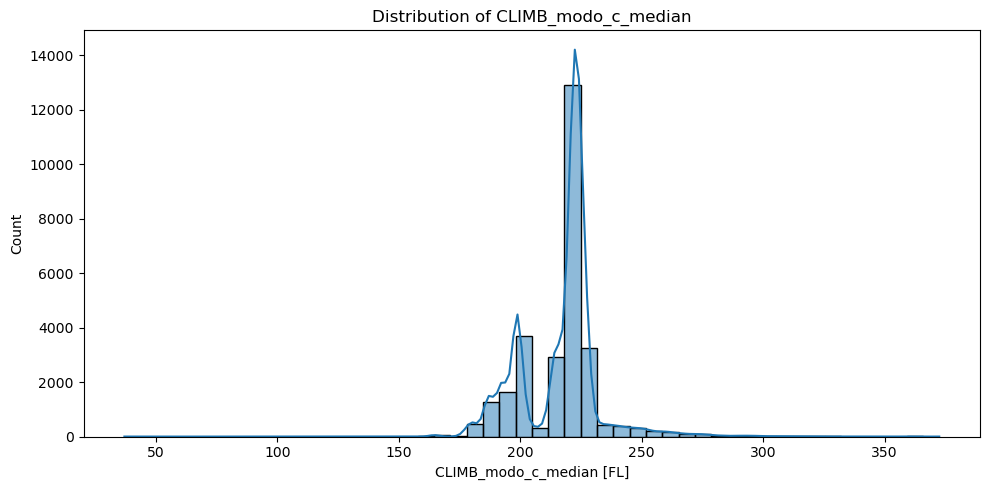

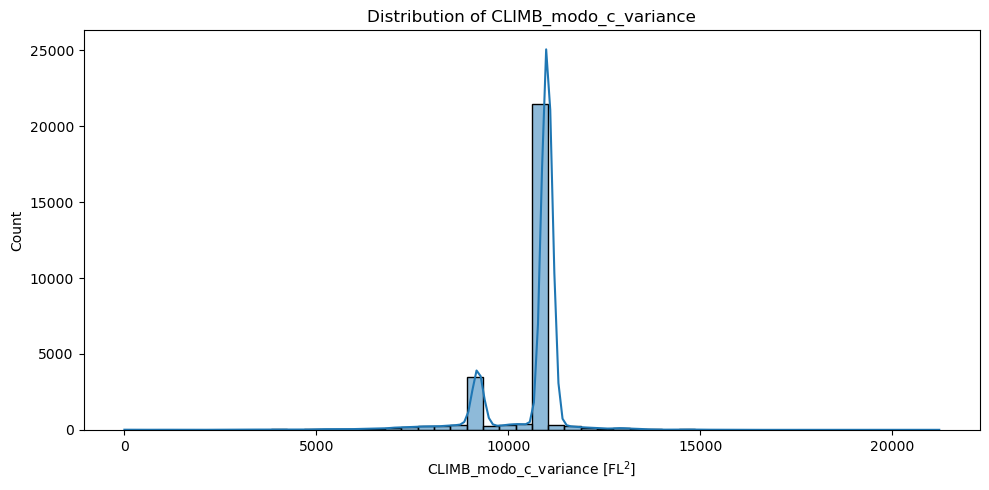

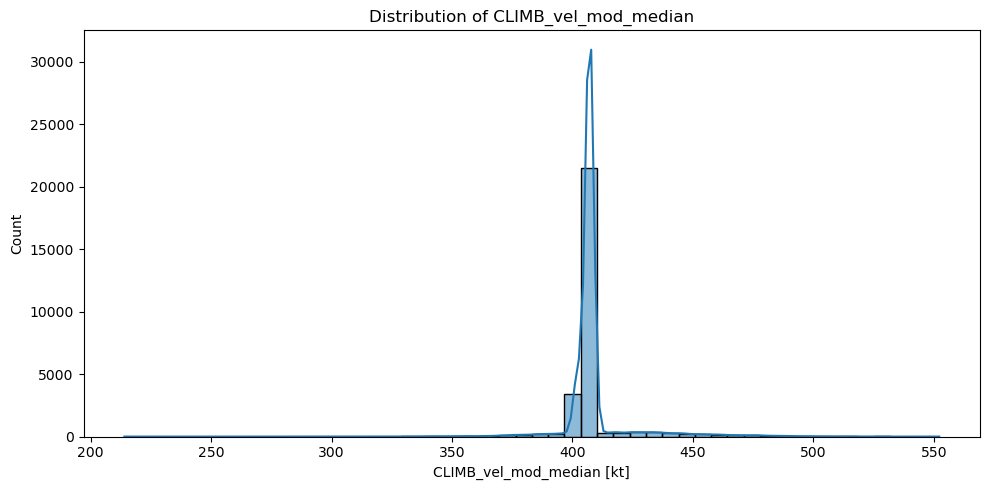

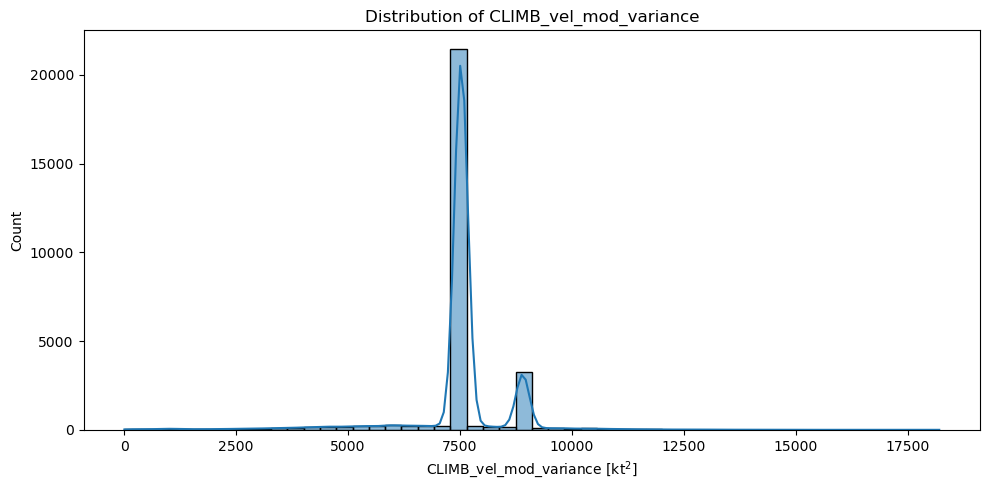

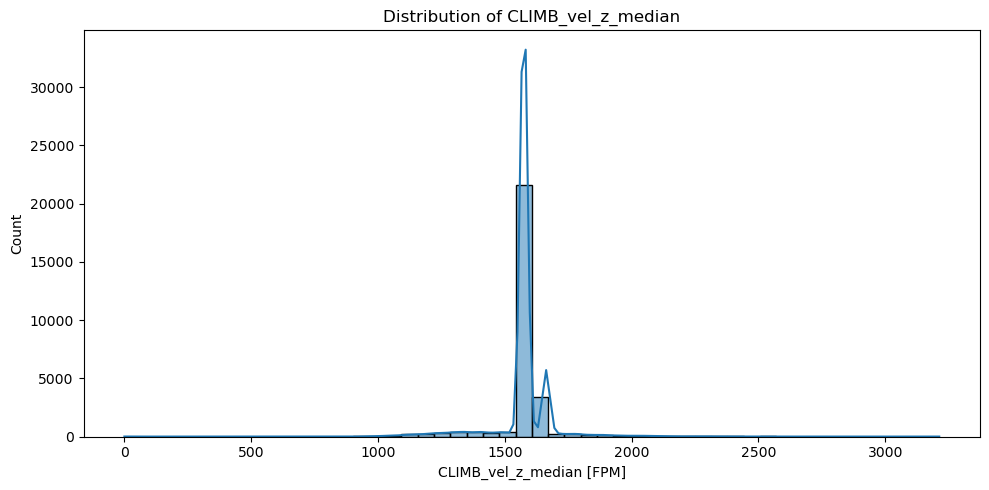

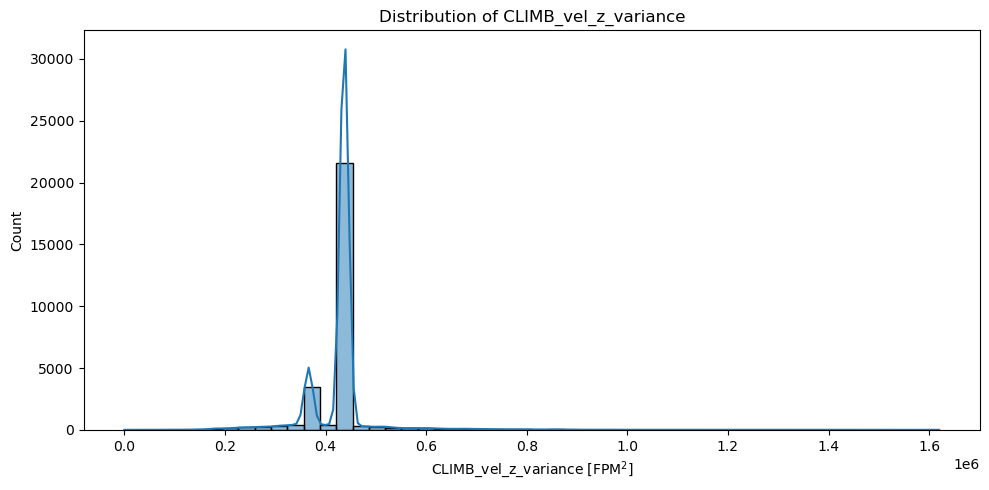

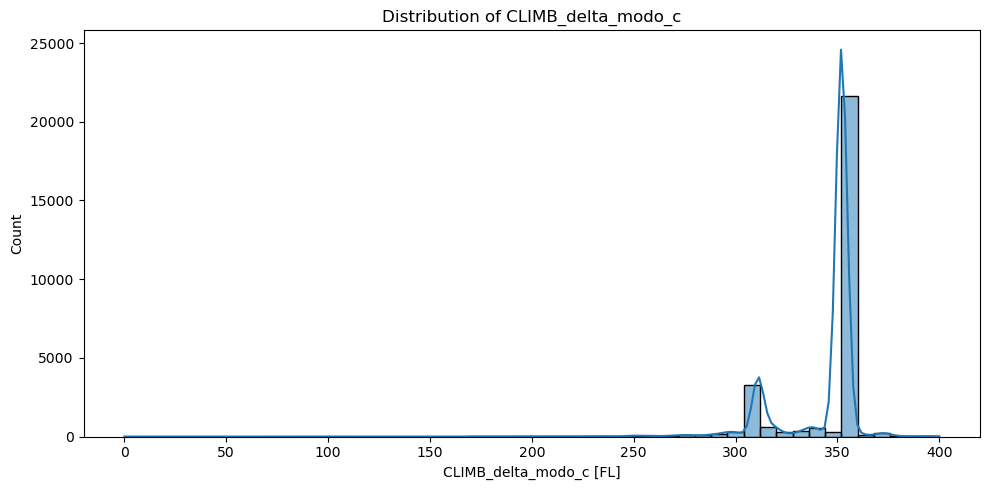

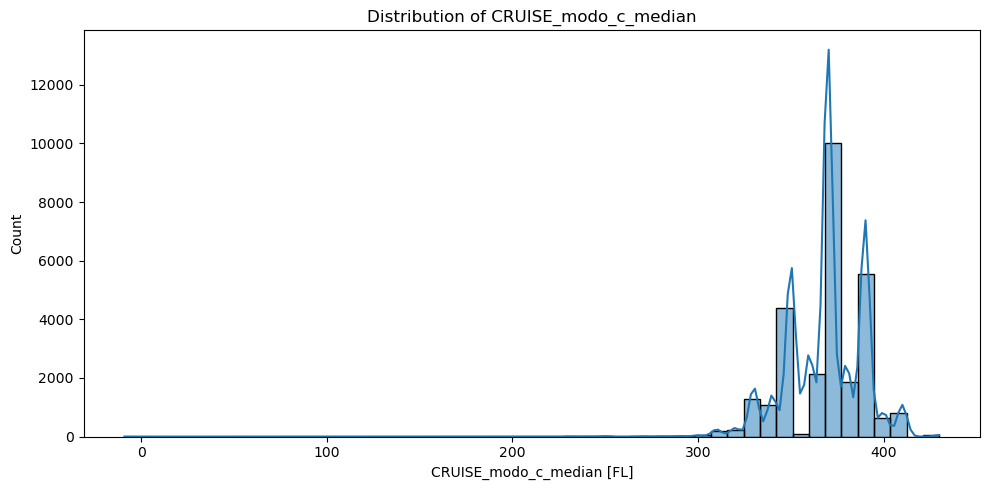

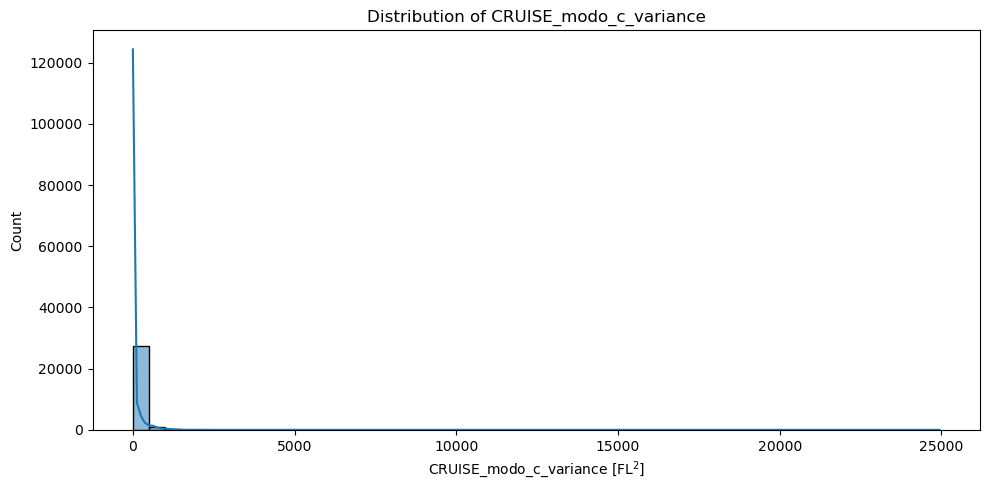

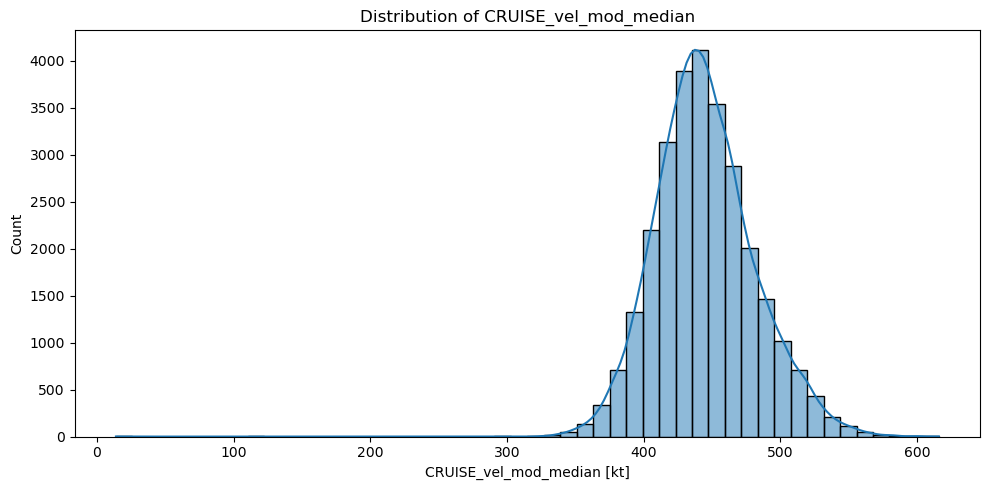

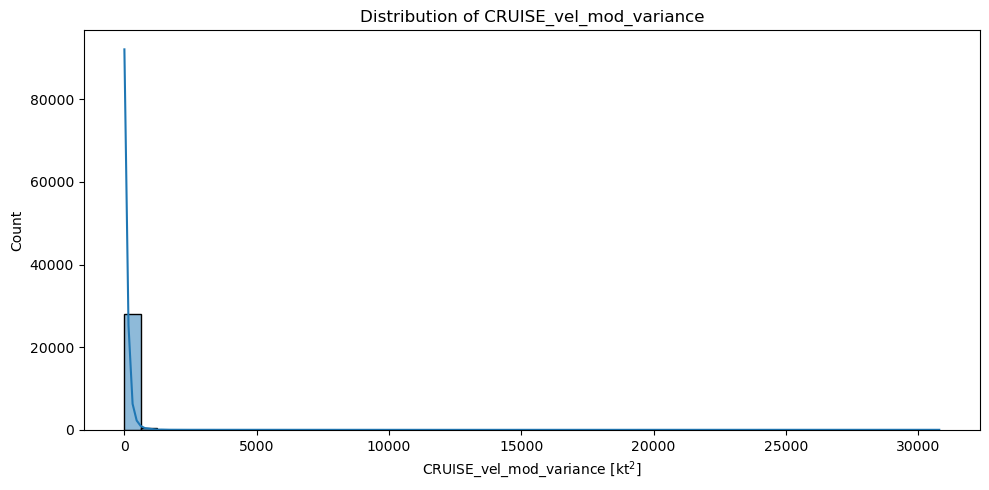

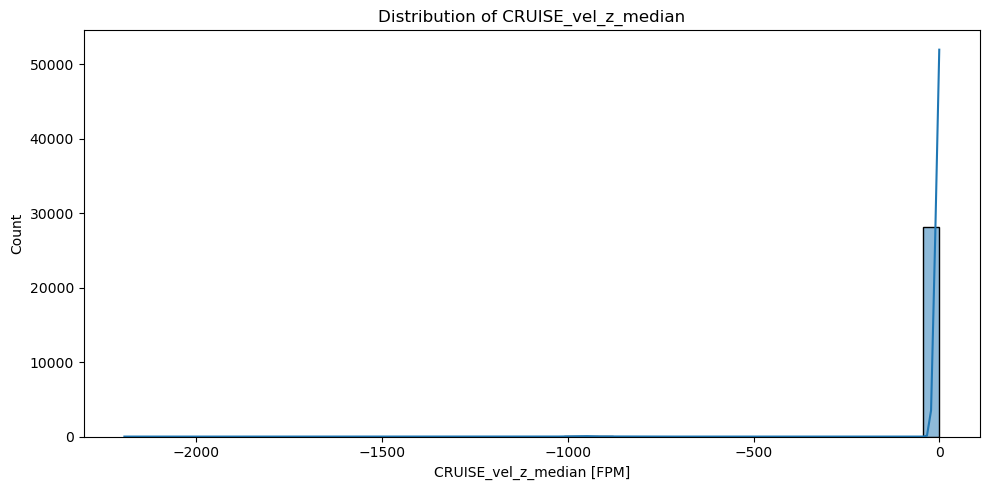

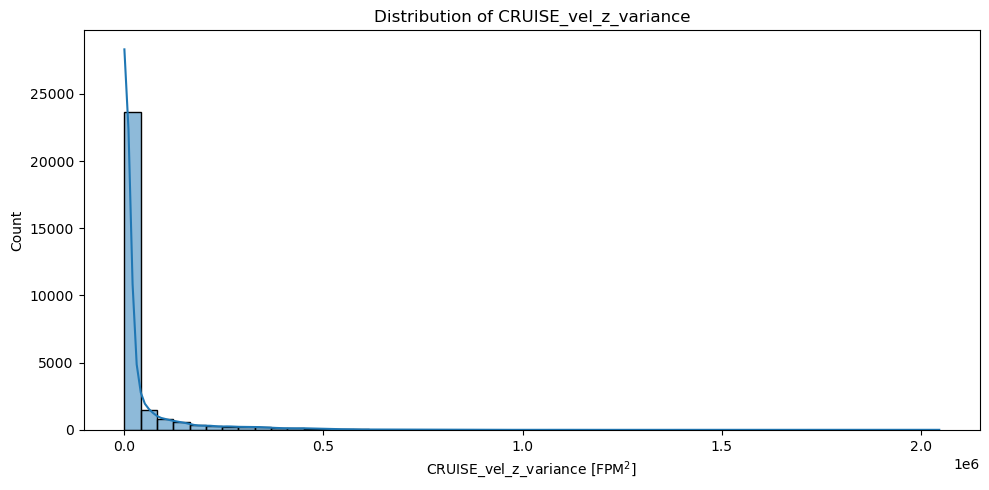

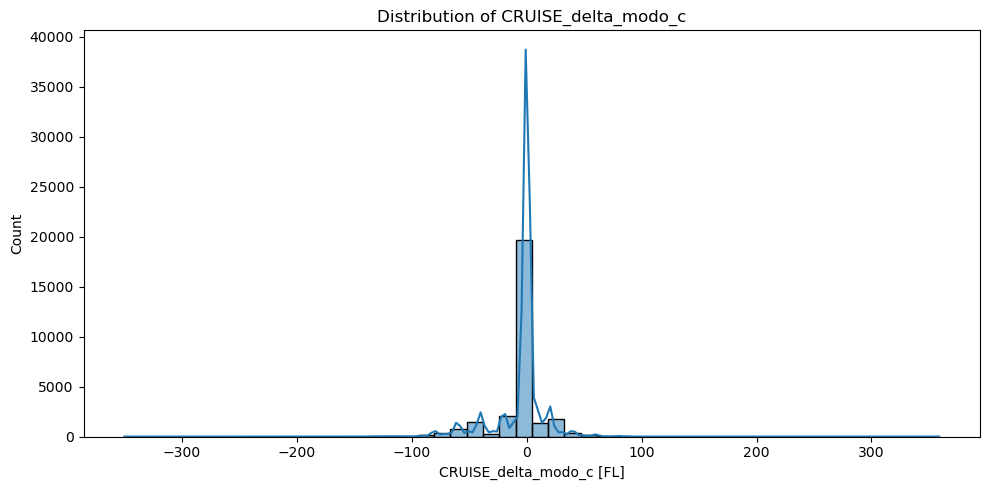

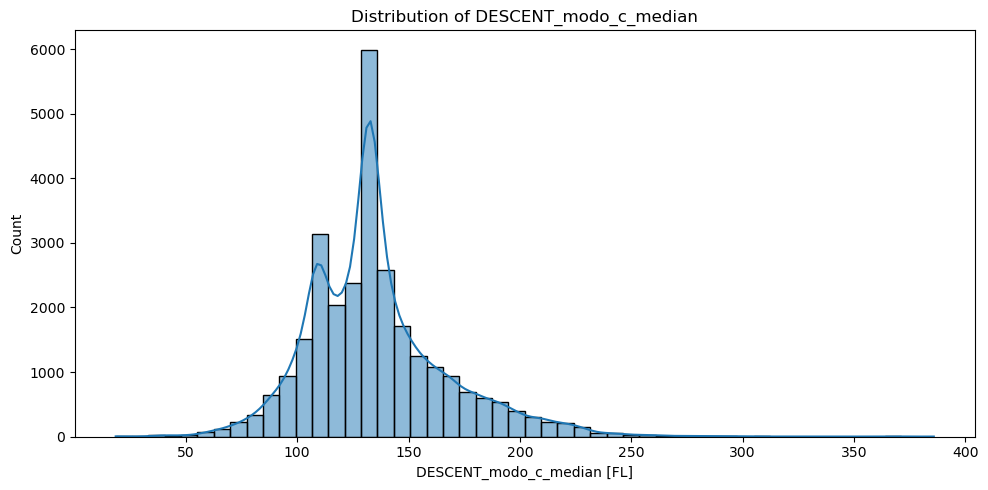

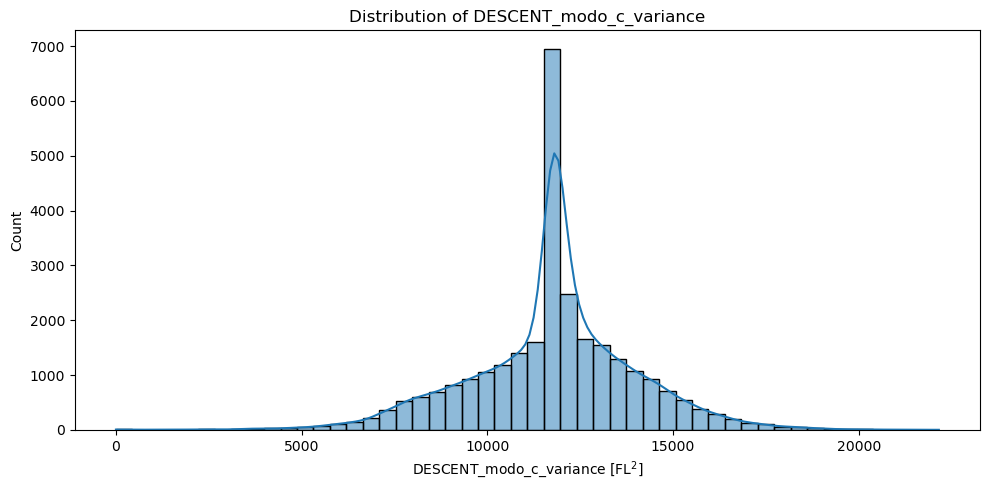

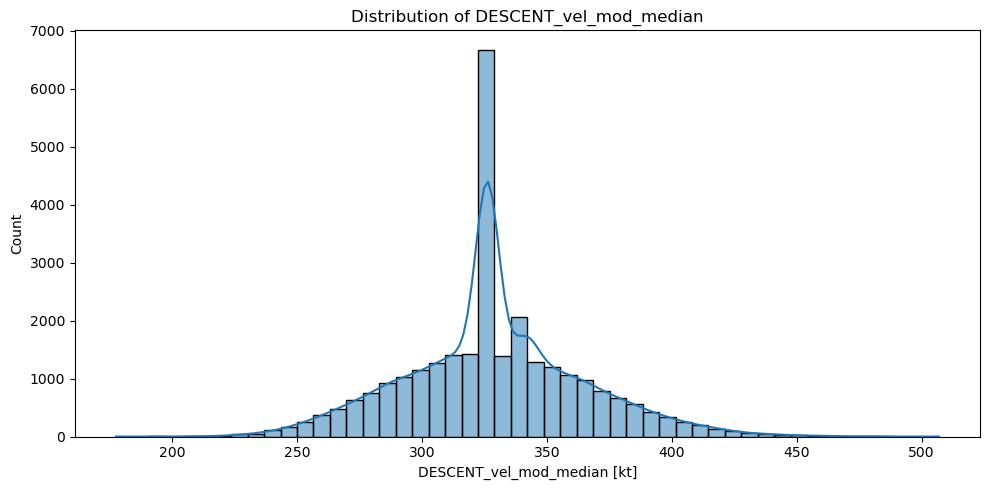

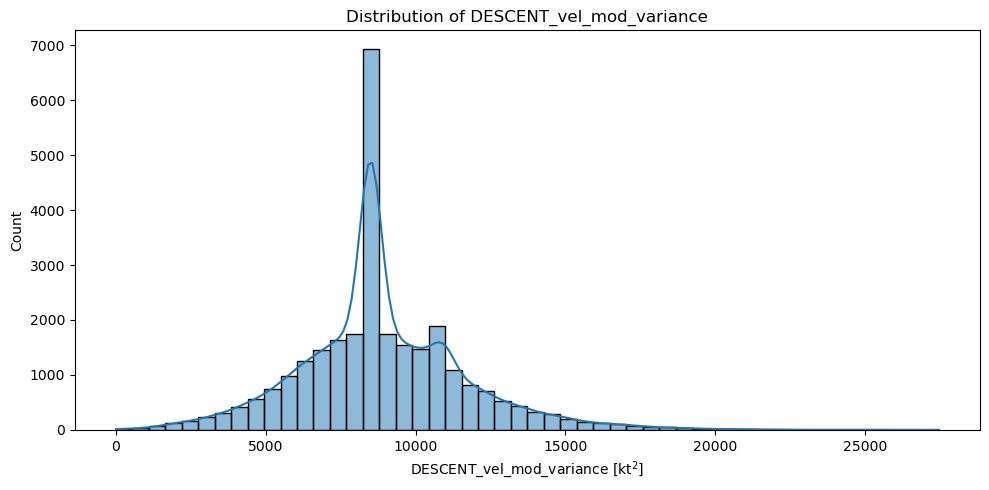

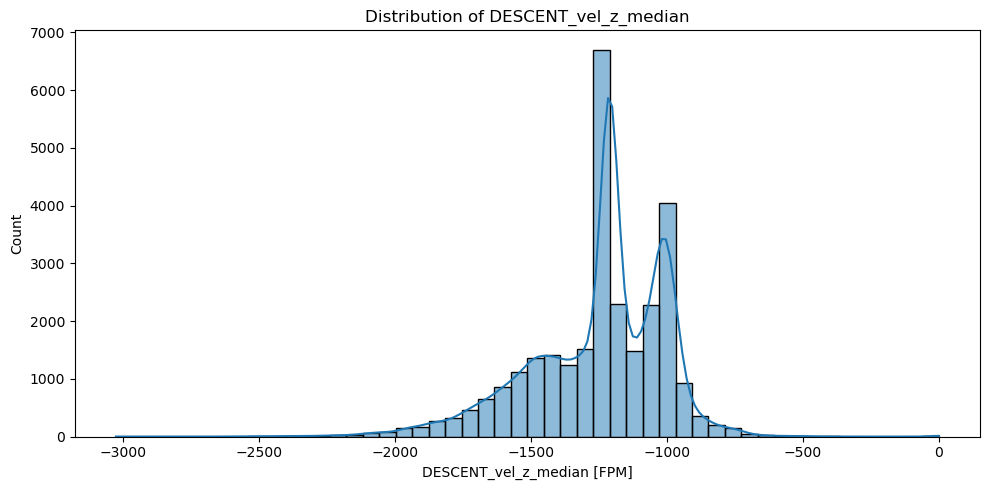

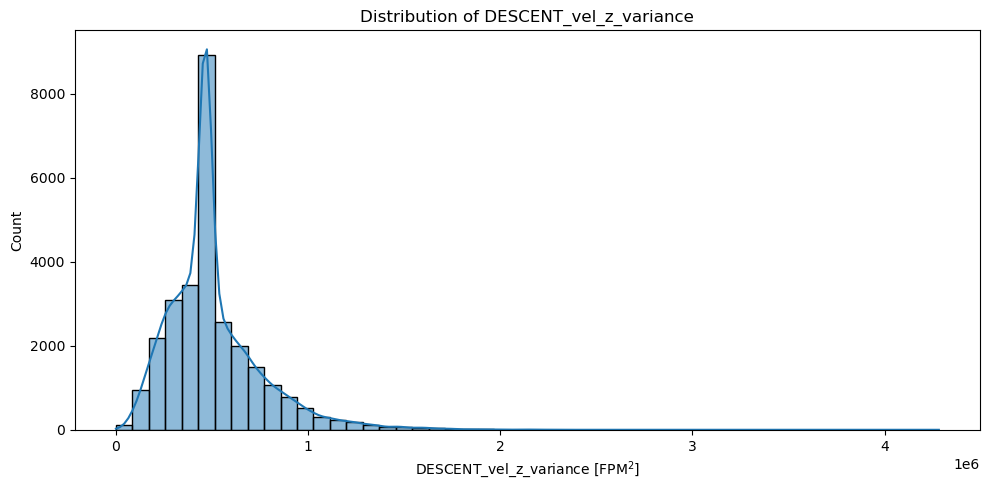

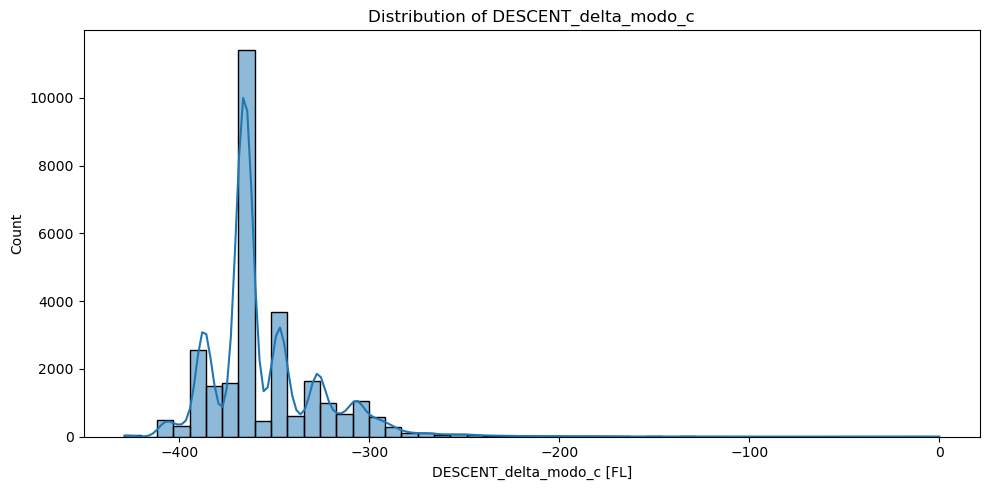

In [8]:
for col in flight_profile_cols:    
    plt.figure(figsize=(10, 5))
    sns.histplot(data[col], bins=50, edgecolor='black', stat='count', kde=True)
    plt.ylabel('Count')
    plt.title(f'Distribution of {col}')
    if 'delta_modo_c' in col:
        plt.xlabel(f'{col} [FL]')
        
    elif 'modo_c_median' in col:
        plt.xlabel(f'{col} [FL]')
    elif 'modo_c_variance' in col:
        plt.xlabel(f'{col} [FL$^2$]')

    elif 'vel_mod_median' in col:
        plt.xlabel(f'{col} [kt]')

    elif 'vel_mod_variance' in col:
        plt.xlabel(f'{col} [kt$^2$]')
        
    elif 'vel_z_median' in col:
        plt.xlabel(f'{col} [FPM]')
    elif 'vel_z_variance' in col:
        plt.xlabel(f'{col} [FPM$^2$]')                                
    plt.tight_layout()
    # plt.savefig(f'{col}.png')
    plt.show()

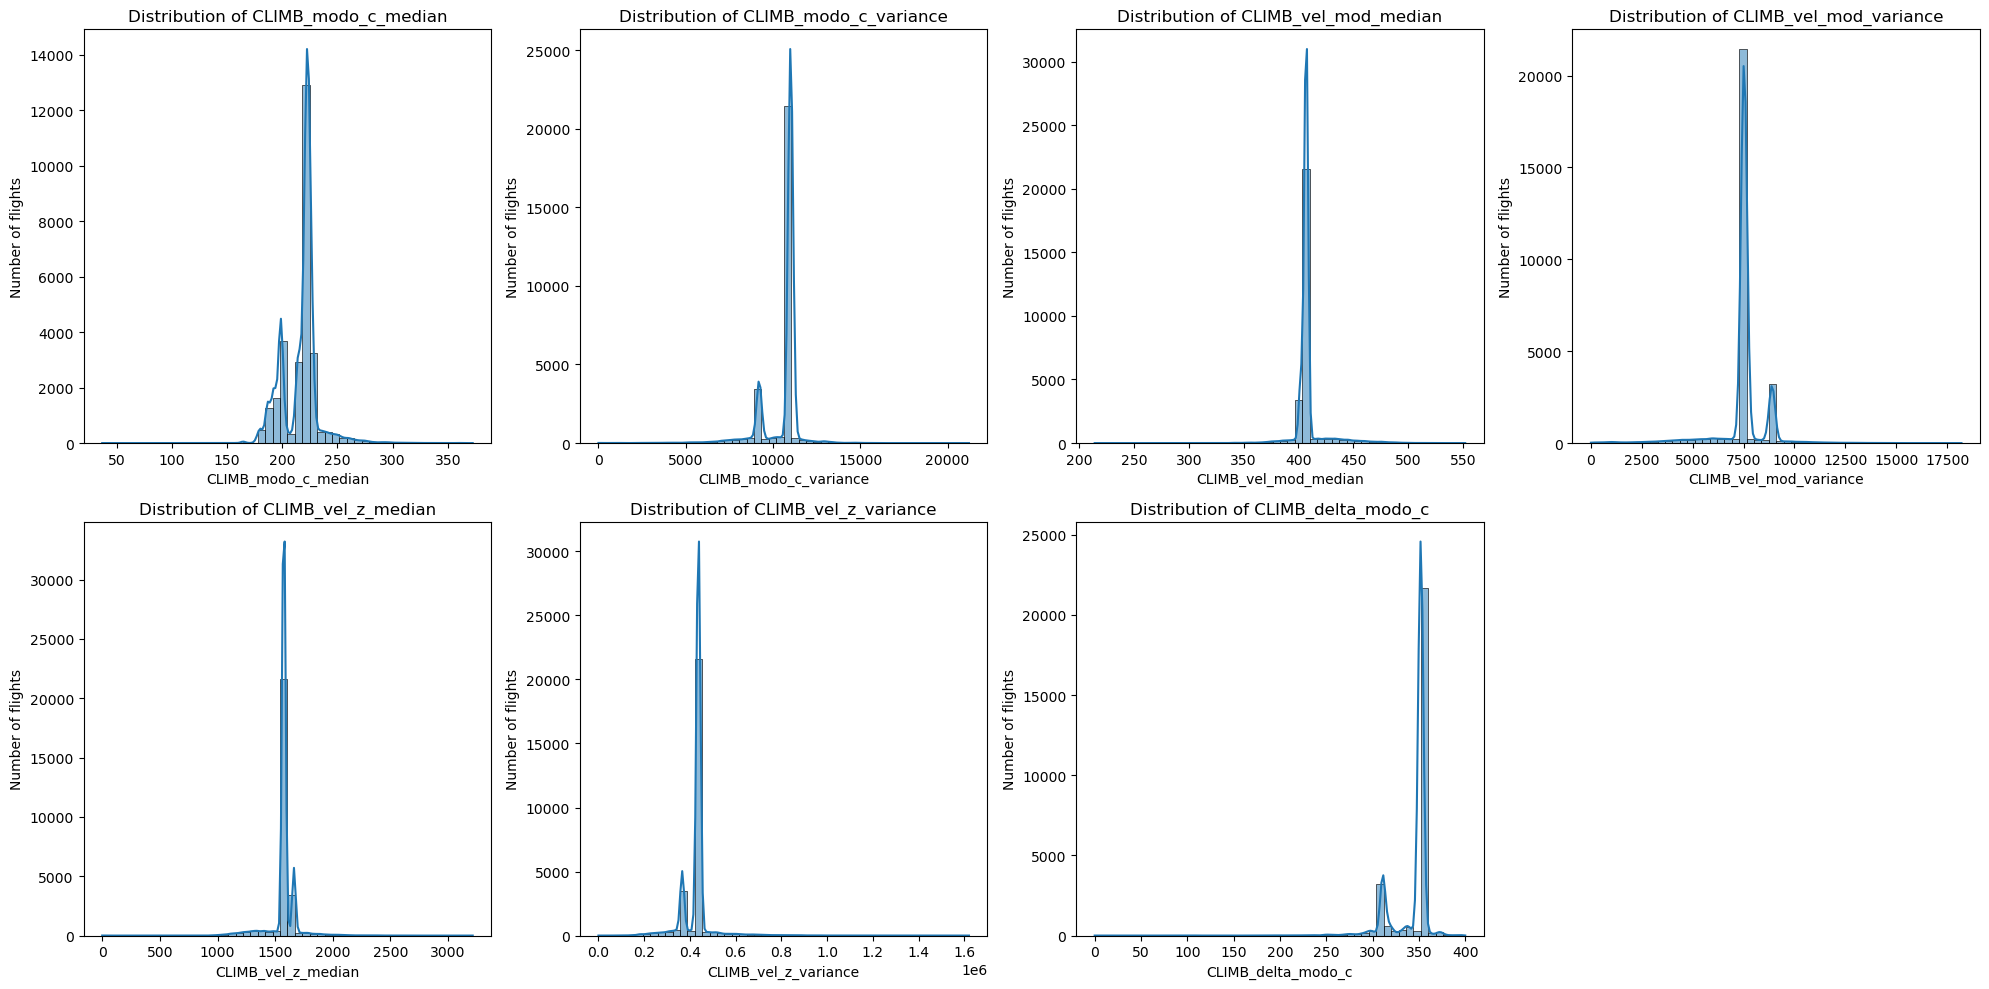

In [9]:
columns = ['CLIMB_modo_c_median', 'CLIMB_modo_c_variance', 'CLIMB_vel_mod_median', 'CLIMB_vel_mod_variance', 'CLIMB_vel_z_median', 'CLIMB_vel_z_variance', 'CLIMB_delta_modo_c']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))  
axes = axes.flatten()  
for i, col in enumerate(columns):
    sns.histplot(data[col], bins=50, edgecolor='black', stat='count', kde=True, ax=axes[i])
    axes[i].set_xlabel(f'{col}')
    axes[i].set_ylabel('Number of flights')
    axes[i].set_title(f'Distribution of {col}')

# Hide the empty subplot (if any)
if len(columns) < len(axes):
    axes[len(columns)].axis('off')

plt.tight_layout()  
plt.show()

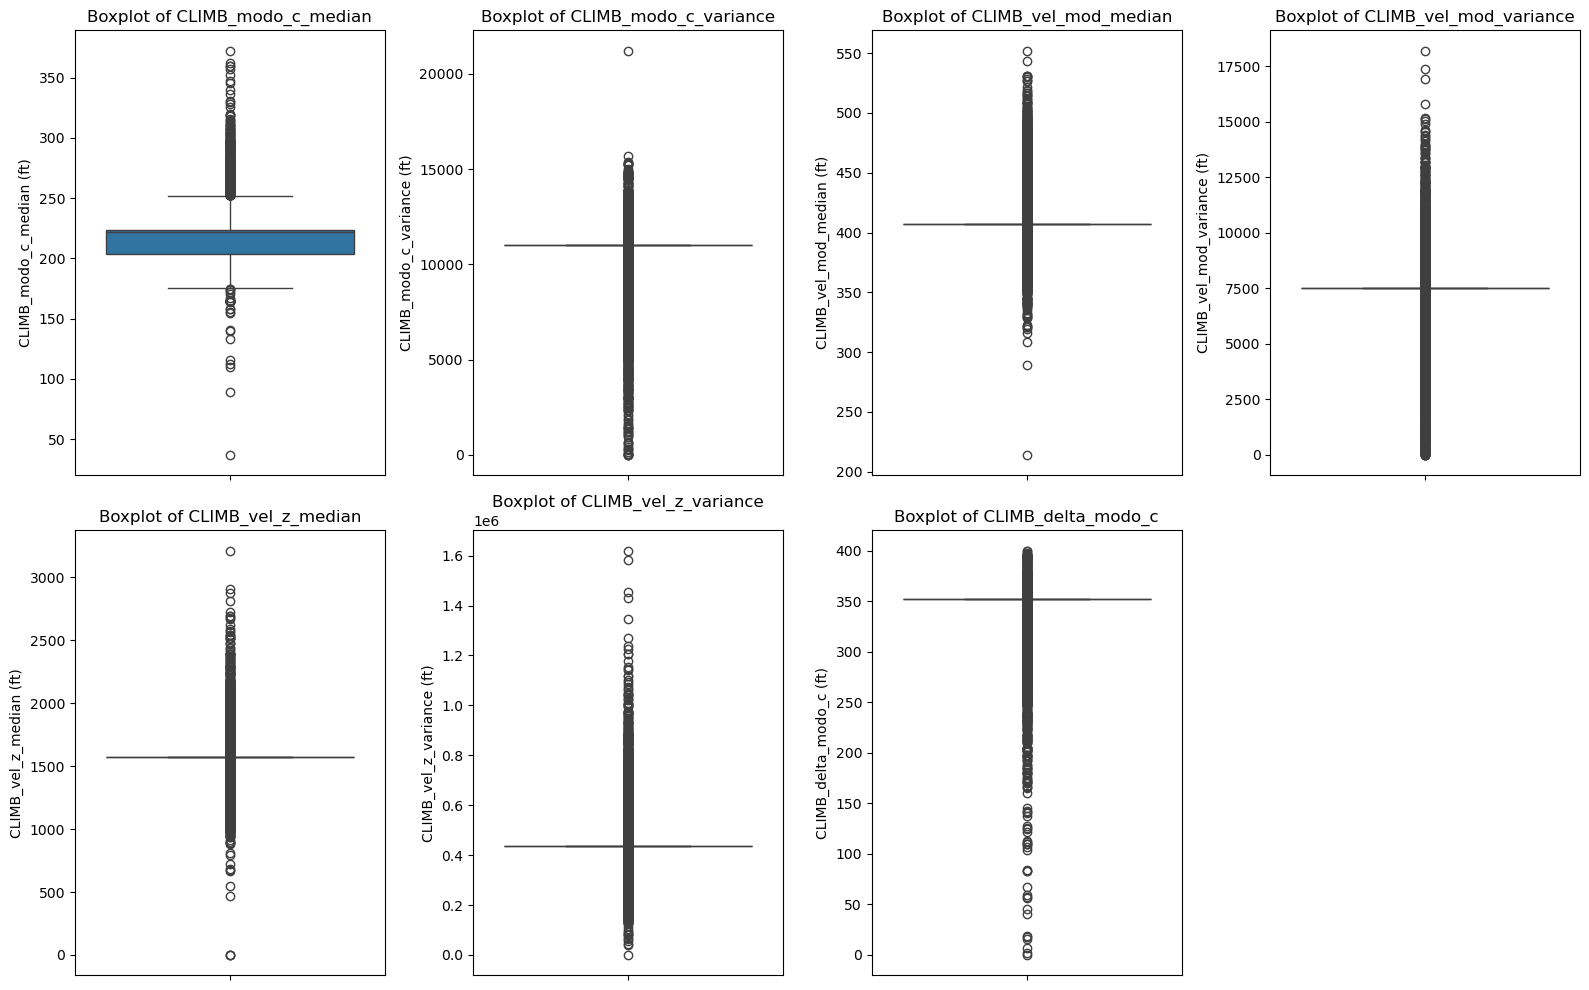

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 10))  
axes = axes.flatten()  

columns = ['CLIMB_modo_c_median', 'CLIMB_modo_c_variance', 'CLIMB_vel_mod_median', 'CLIMB_vel_mod_variance', 'CLIMB_vel_z_median', 'CLIMB_vel_z_variance', 'CLIMB_delta_modo_c']

for c in columns:
    quartiles = data[c].describe()
    iqr = (quartiles['75%'] - quartiles['25%'])
    upper = quartiles['75%'] + (iqr*1.5)
    lower = quartiles['25%'] - (iqr*1.5)
for i, col in enumerate(columns):
    sns.boxplot(y=data[col], ax=axes[i])
    axes[i].set_ylabel(f'{col} (ft)')
    axes[i].set_title(f'Boxplot of {col}')

# Hide the empty subplot (if any)
if len(columns) < len(axes):
    axes[len(columns)].axis('off')

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

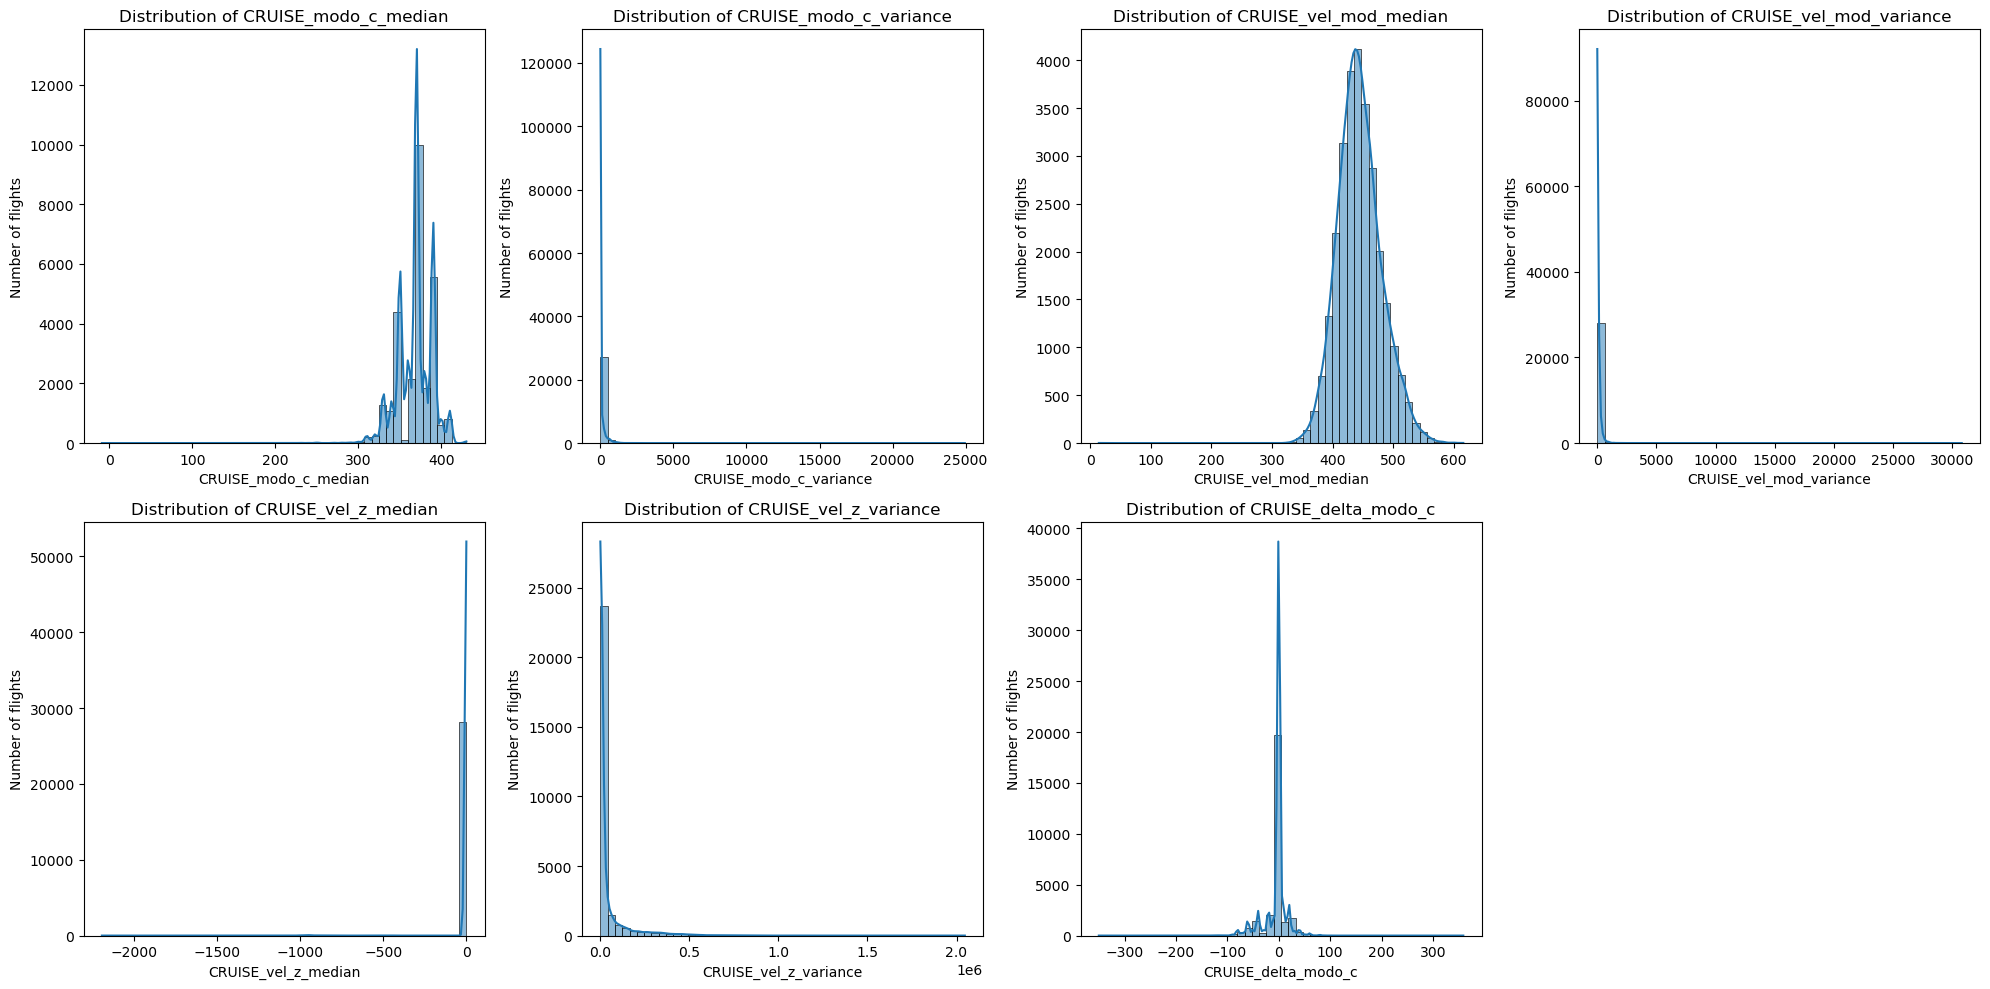

In [11]:
columns = ['CRUISE_modo_c_median', 'CRUISE_modo_c_variance', 'CRUISE_vel_mod_median', 'CRUISE_vel_mod_variance', 'CRUISE_vel_z_median', 'CRUISE_vel_z_variance', 'CRUISE_delta_modo_c']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))  
axes = axes.flatten()  
for i, col in enumerate(columns):
    sns.histplot(data[col], bins=50, edgecolor='black', stat='count', kde=True, ax=axes[i])
    axes[i].set_xlabel(f'{col}')
    axes[i].set_ylabel('Number of flights')
    axes[i].set_title(f'Distribution of {col}')

# Hide the empty subplot (if any)
if len(columns) < len(axes):
    axes[len(columns)].axis('off')

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

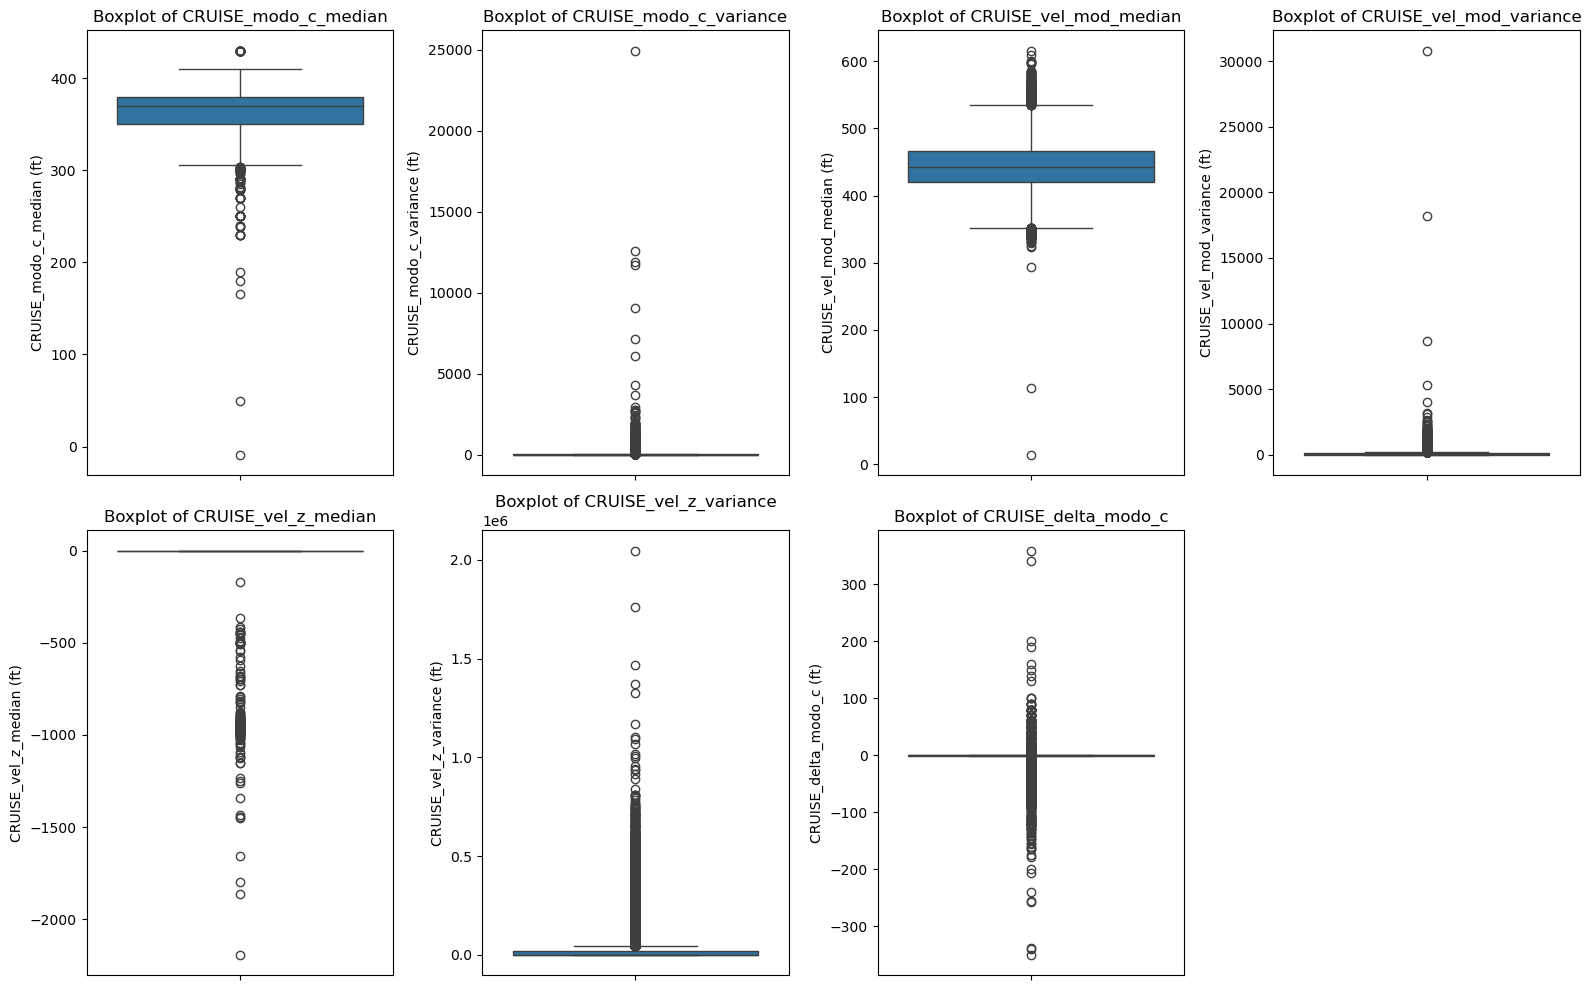

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(16, 10))  
axes = axes.flatten()  

columns = ['CRUISE_modo_c_median', 'CRUISE_modo_c_variance', 'CRUISE_vel_mod_median', 'CRUISE_vel_mod_variance', 'CRUISE_vel_z_median', 'CRUISE_vel_z_variance', 'CRUISE_delta_modo_c']

for c in columns:
    quartiles = data[c].describe()
    iqr = (quartiles['75%'] - quartiles['25%'])
    upper = quartiles['75%'] + (iqr*1.5)
    lower = quartiles['25%'] - (iqr*1.5)

for i, col in enumerate(columns):
    sns.boxplot(y=data[col], ax=axes[i])
    axes[i].set_ylabel(f'{col} (ft)')
    axes[i].set_title(f'Boxplot of {col}')

# Hide the empty subplot (if any)
if len(columns) < len(axes):
    axes[len(columns)].axis('off')

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

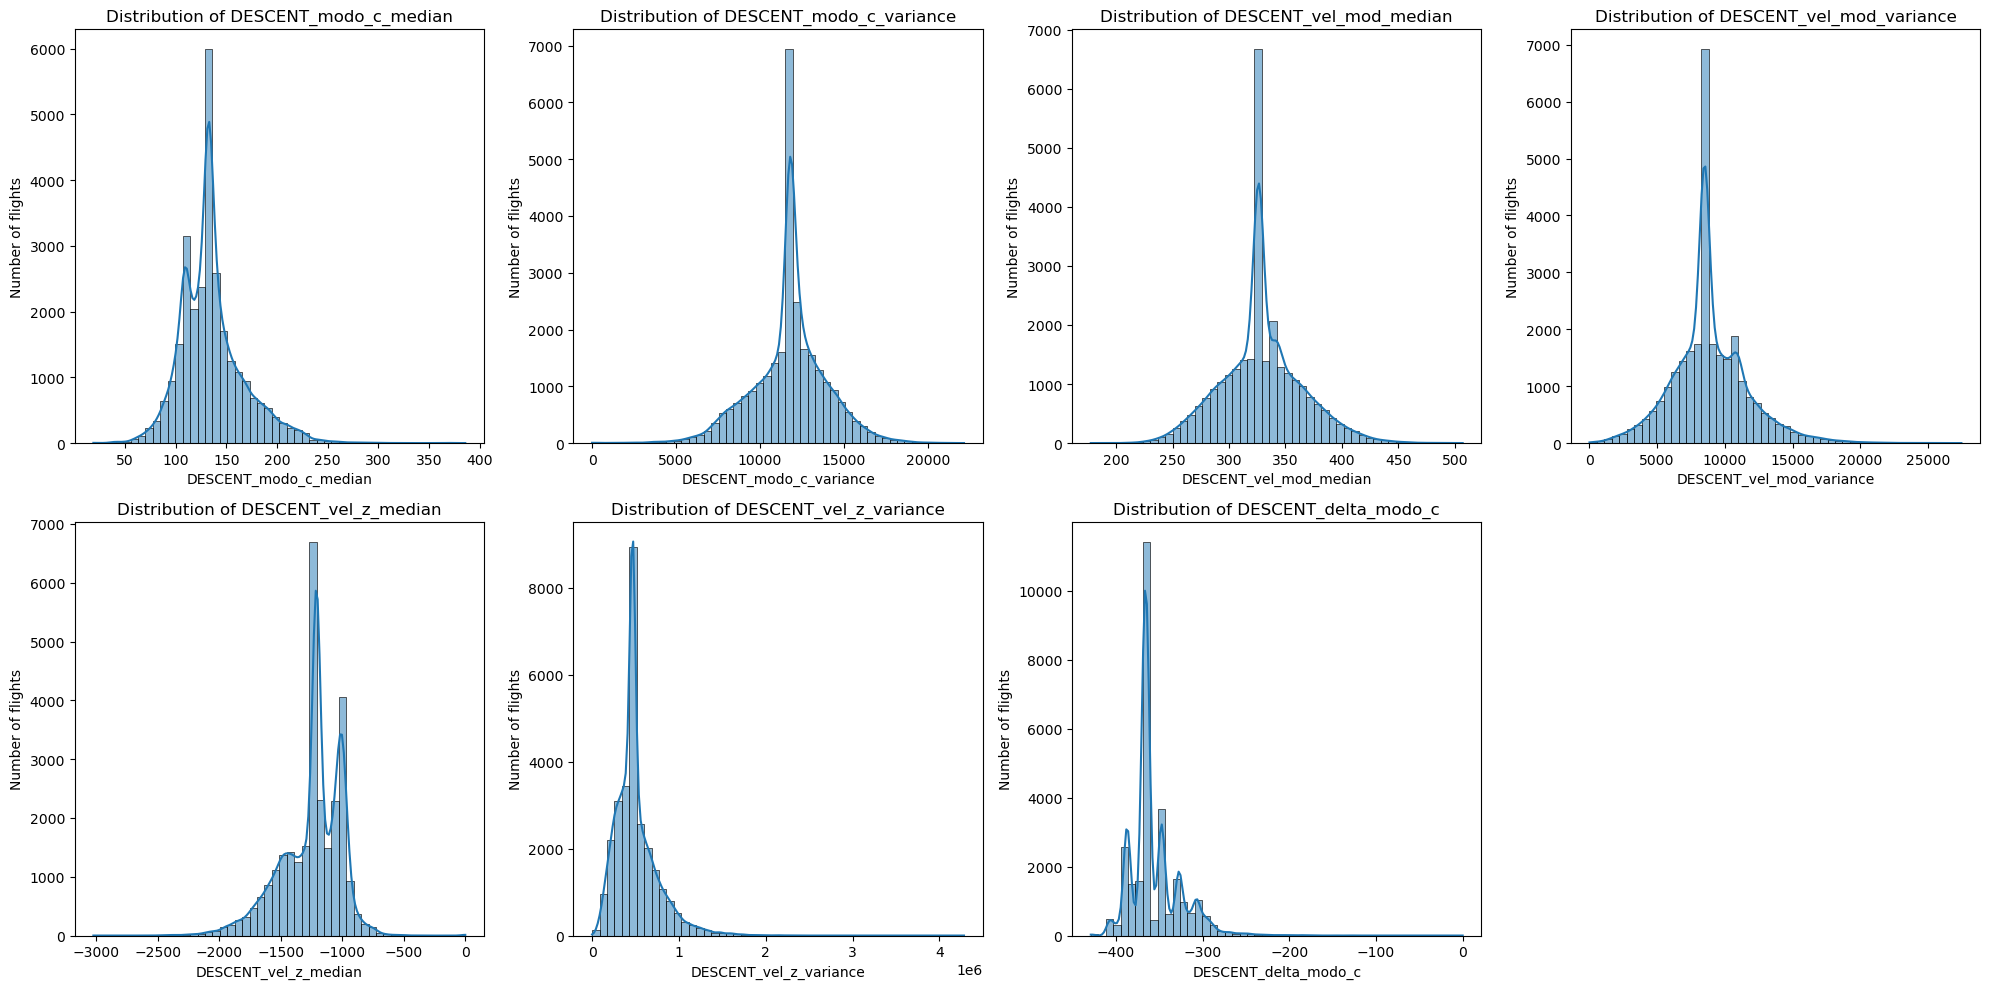

In [13]:
columns = ['DESCENT_modo_c_median', 'DESCENT_modo_c_variance', 'DESCENT_vel_mod_median', 'DESCENT_vel_mod_variance', 'DESCENT_vel_z_median', 'DESCENT_vel_z_variance', 'DESCENT_delta_modo_c']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))  
axes = axes.flatten()  
for i, col in enumerate(columns):
    sns.histplot(data[col], bins=50, edgecolor='black', stat='count', kde=True, ax=axes[i])
    axes[i].set_xlabel(f'{col}')
    axes[i].set_ylabel('Number of flights')
    axes[i].set_title(f'Distribution of {col}')

# Hide the empty subplot (if any)
if len(columns) < len(axes):
    axes[len(columns)].axis('off')

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

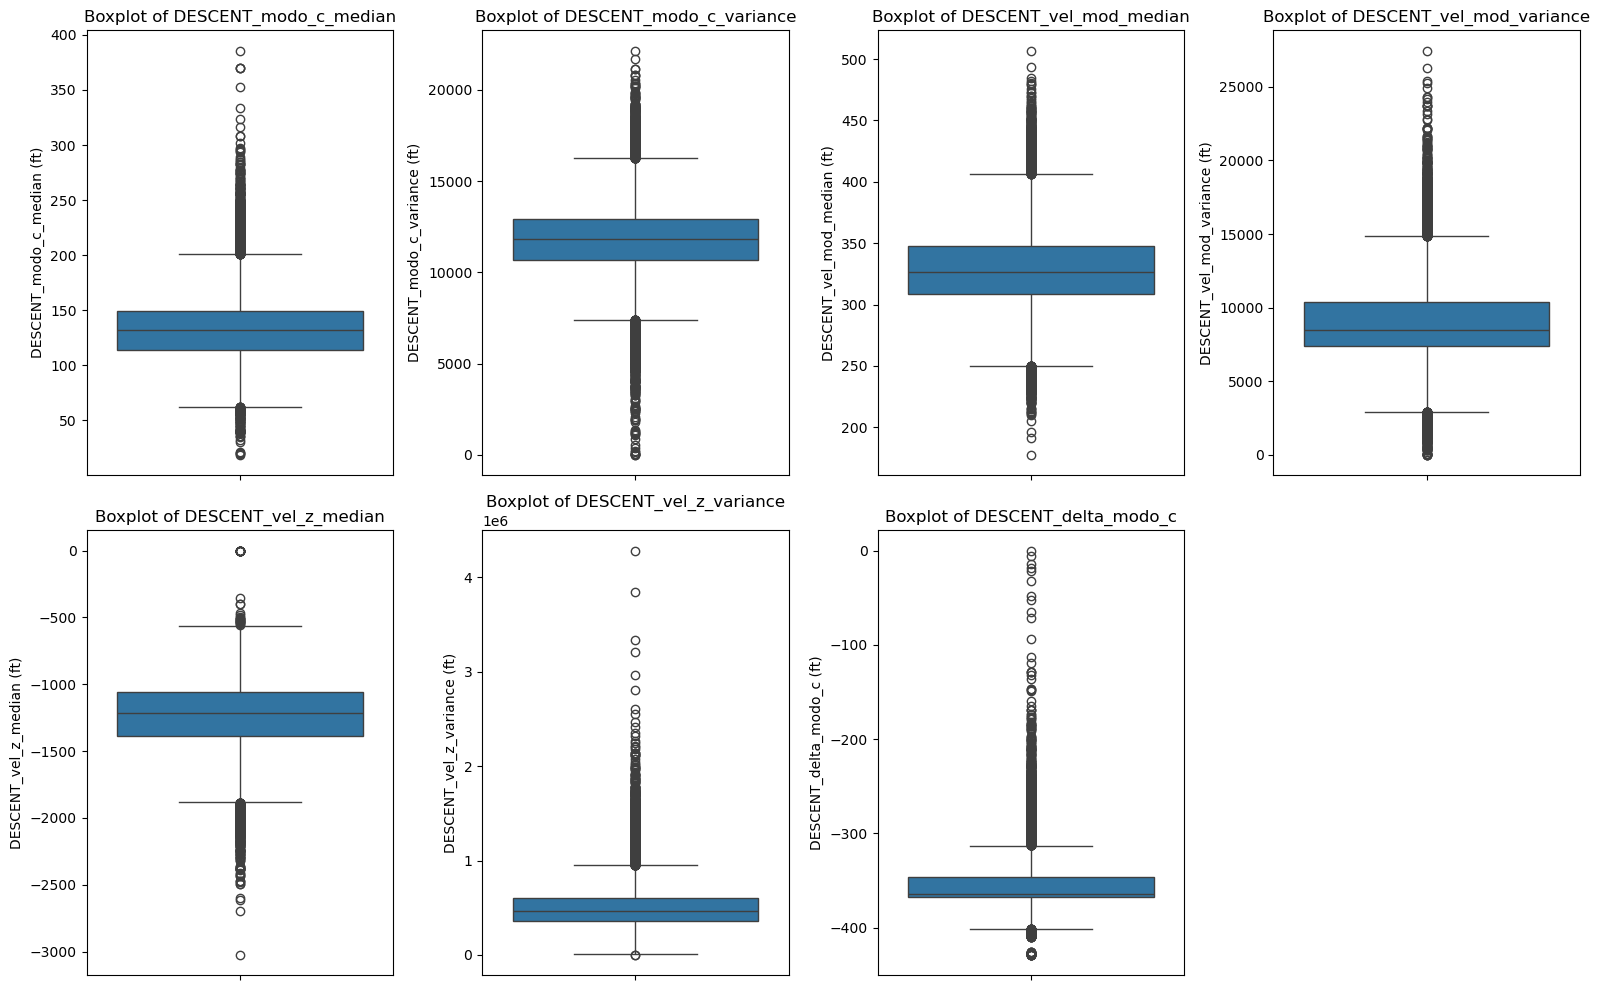

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(16, 10))  
axes = axes.flatten()  

columns = ['DESCENT_modo_c_median', 'DESCENT_modo_c_variance', 'DESCENT_vel_mod_median', 'DESCENT_vel_mod_variance', 'DESCENT_vel_z_median', 'DESCENT_vel_z_variance', 'DESCENT_delta_modo_c']

for c in columns:
    quartiles = data[c].describe()
    iqr = (quartiles['75%'] - quartiles['25%'])
    upper = quartiles['75%'] + (iqr*1.5)
    lower = quartiles['25%'] - (iqr*1.5)
    
for i, col in enumerate(columns):
    sns.boxplot(y=data[col], ax=axes[i])
    axes[i].set_ylabel(f'{col} (ft)')
    axes[i].set_title(f'Boxplot of {col}')

# Hide the empty subplot (if any)
if len(columns) < len(axes):
    axes[len(columns)].axis('off')

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

# climbing features: vel_mod, vel_z during 30FL, 60FL, 90FL

In [15]:
# initial_vel_cols = ['CLIMB_vel_mod_mean_30fl', 'CLIMB_vel_mod_mean_60fl', 'CLIMB_vel_mod_mean_90fl', 'CLIMB_vel_z_mean_30fl', 'CLIMB_vel_z_mean_60fl', 'CLIMB_vel_z_mean_90fl'] 
intervals = [
    '0-30fl', 
    '0-60fl', 
    '0-90fl',
    '30-60fl', 
    '30-90fl', 
    '60-90fl'
]
vel_intervals = []
for label in intervals:
    vel_intervals.append(f'CLIMB_vel_mod_mean_{label}')
    vel_intervals.append(f'CLIMB_vel_z_mean_{label}')
    vel_intervals.append(f'CLIMB_vel_mod_variance_{label}')
    vel_intervals.append(f'CLIMB_vel_z_variance_{label}')
    
len(vel_intervals)

24

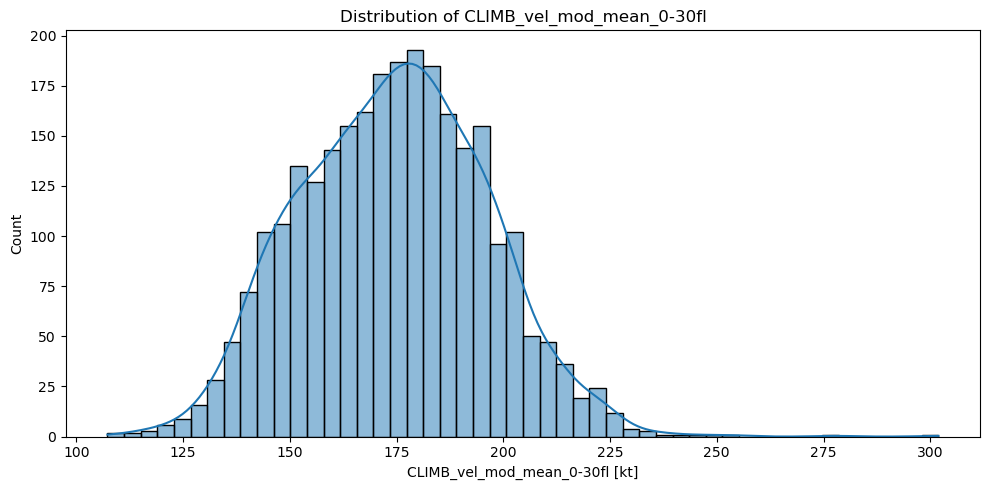

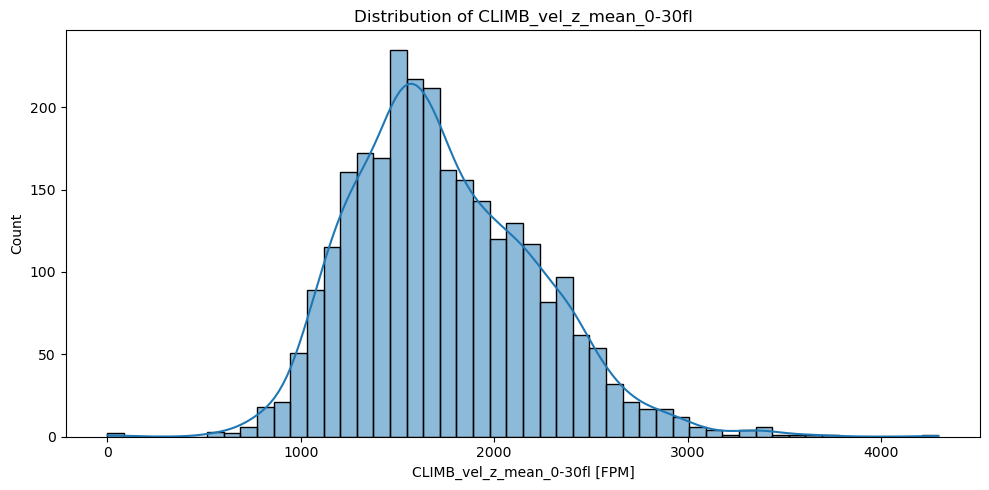

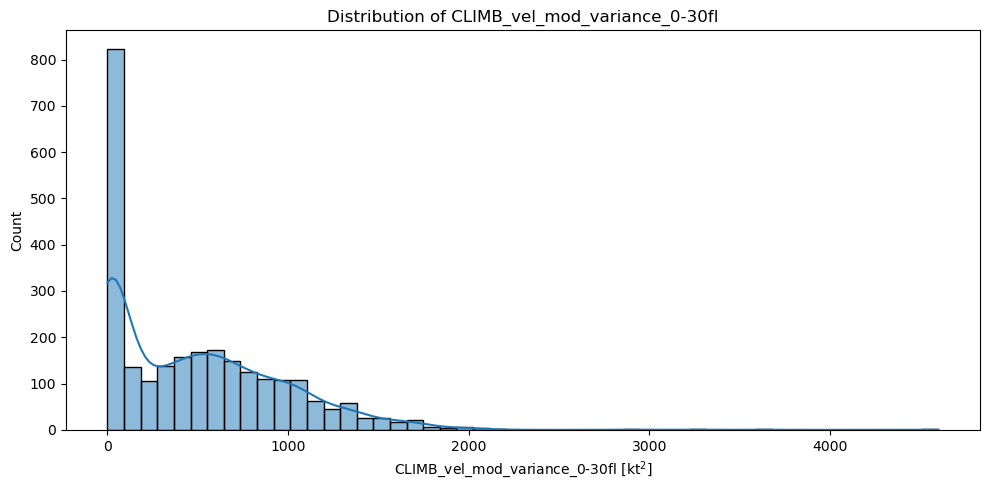

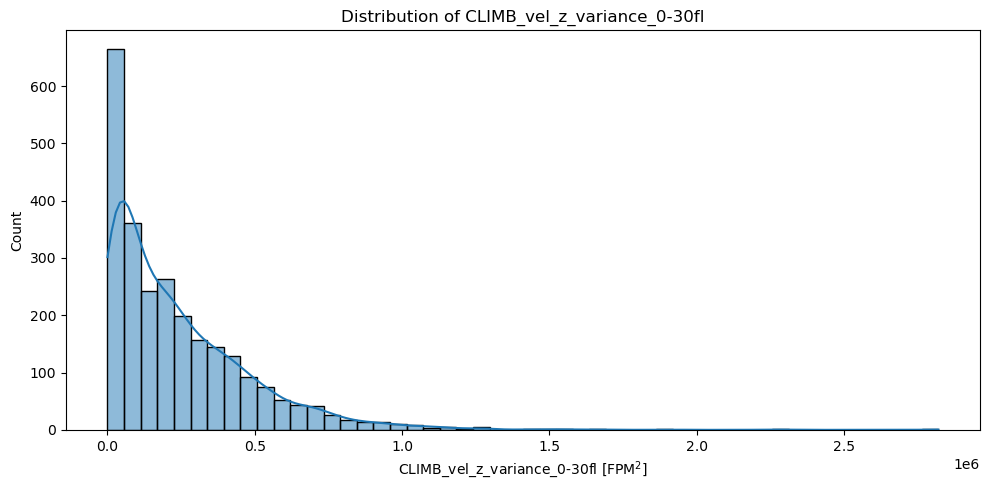

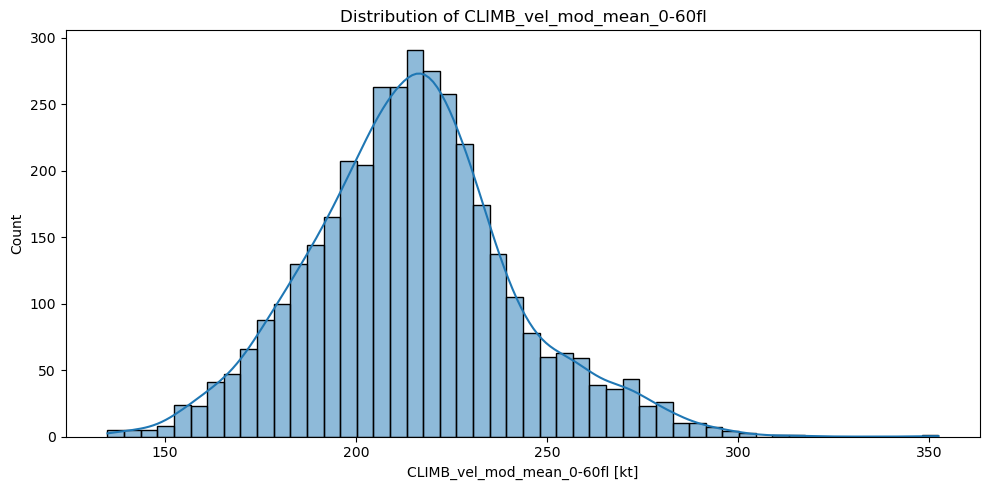

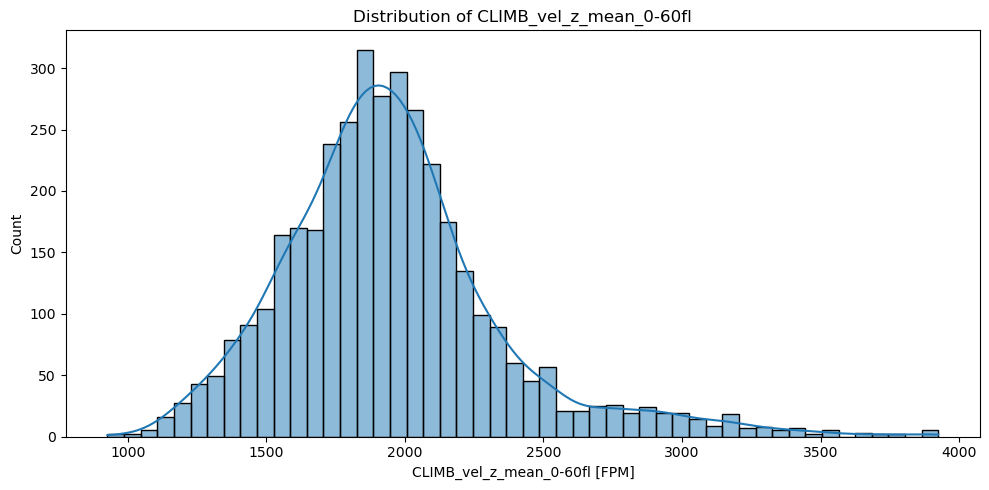

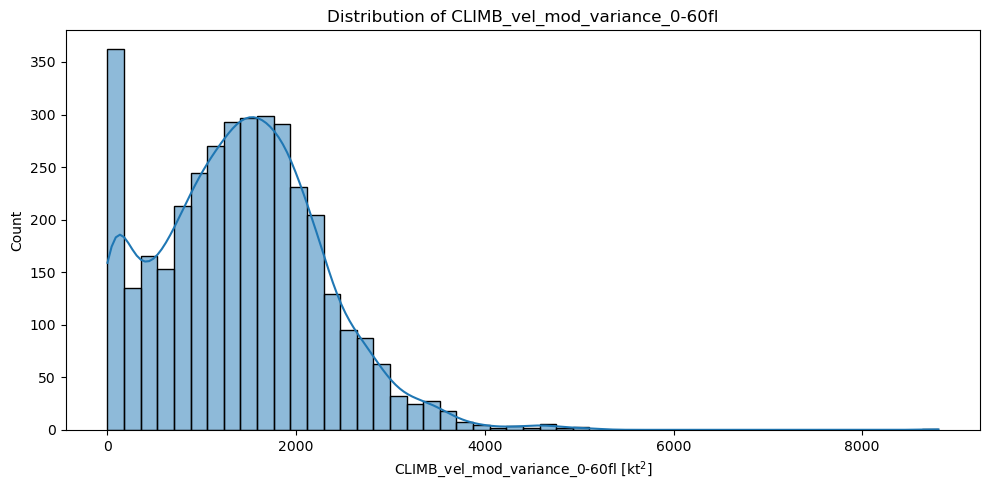

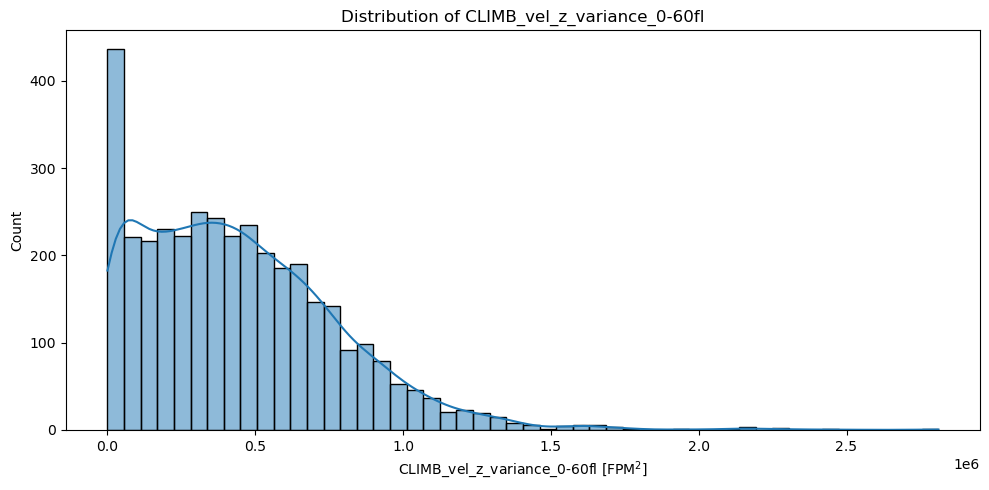

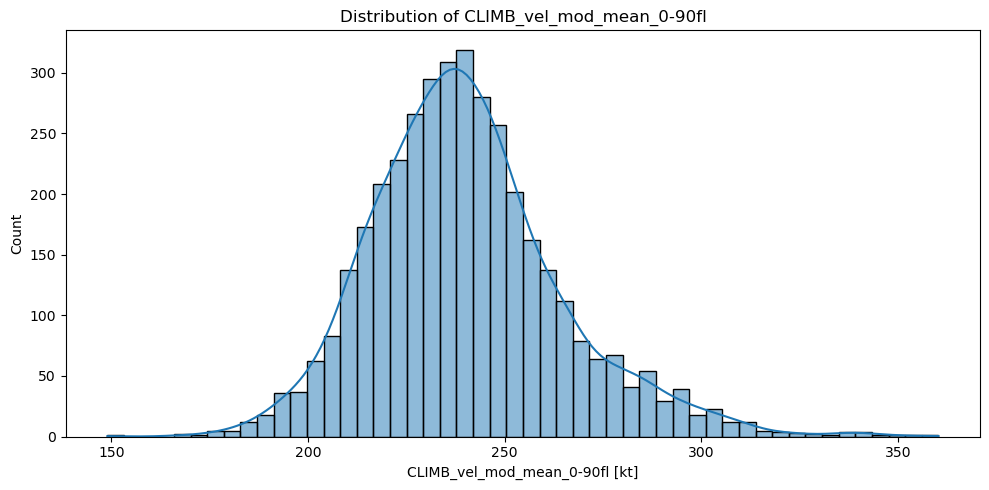

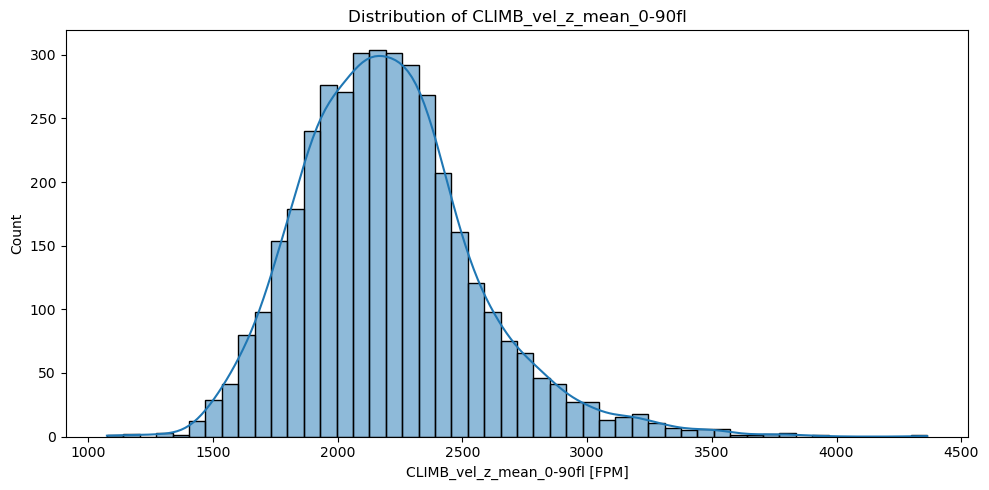

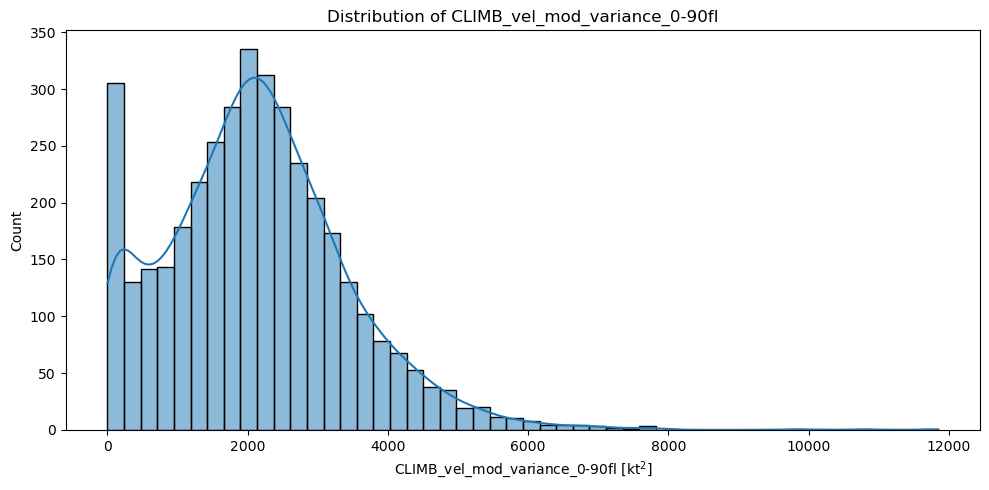

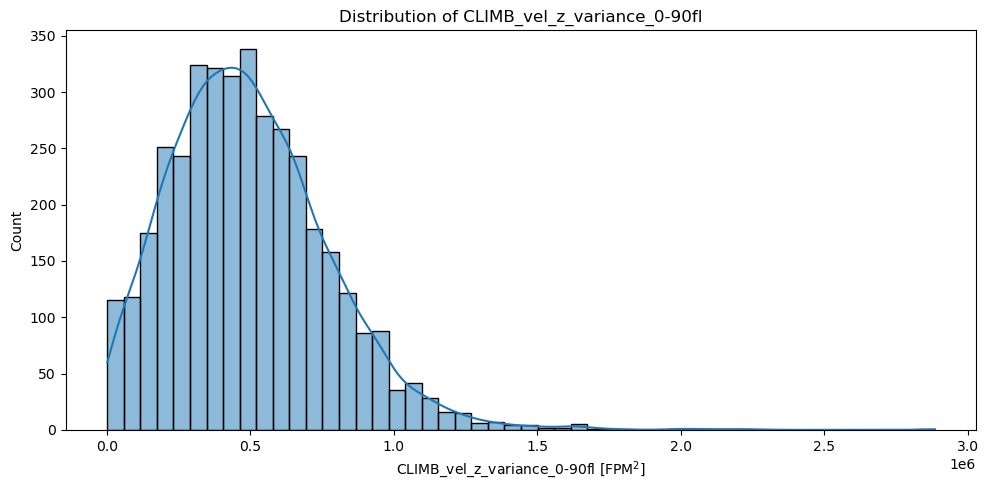

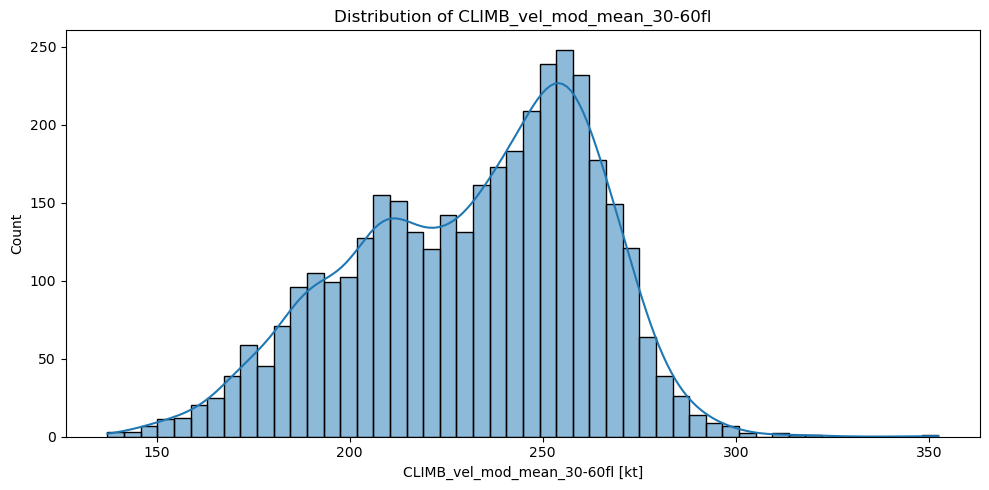

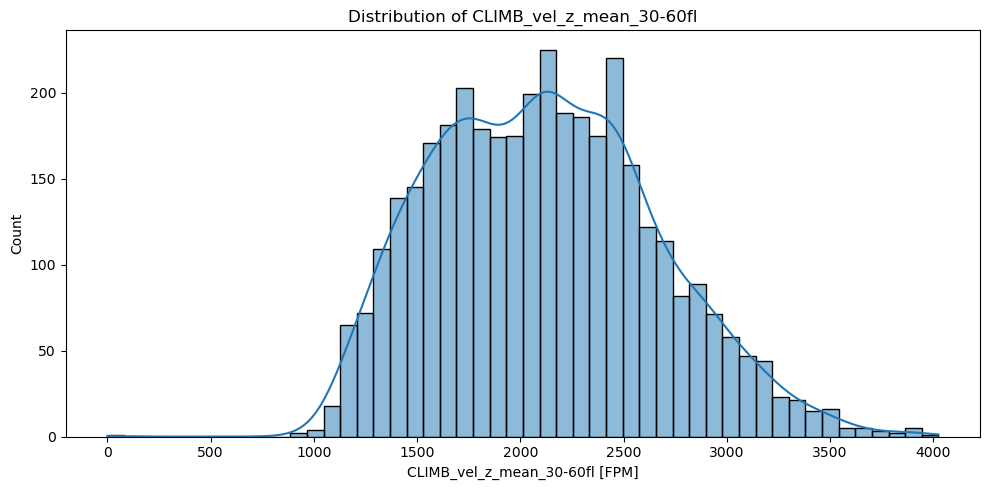

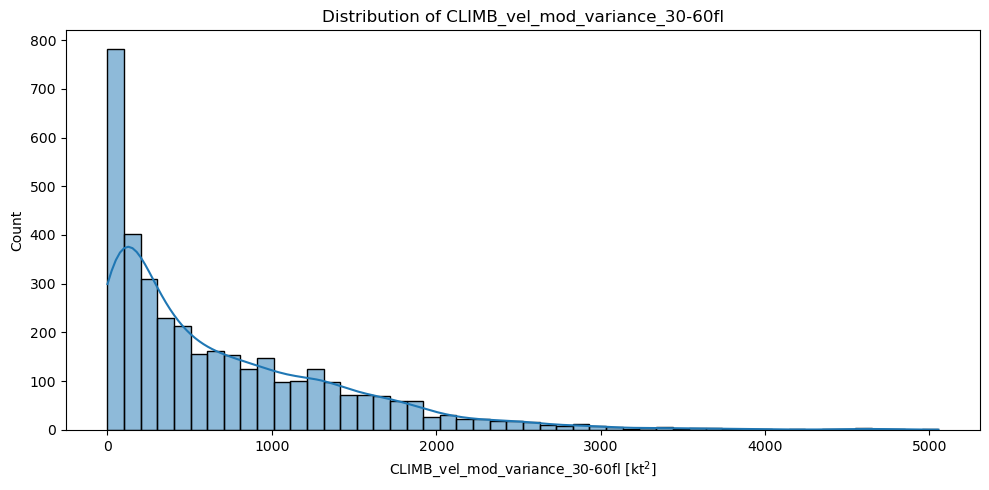

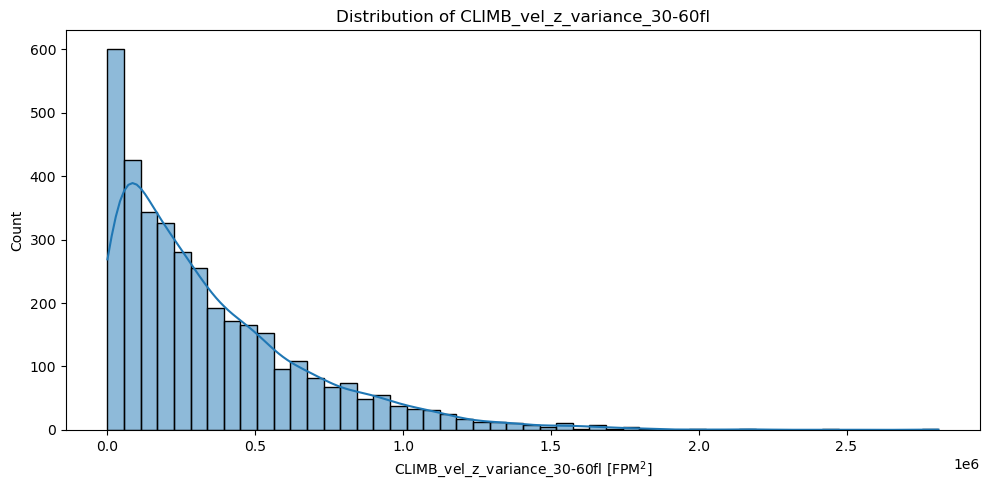

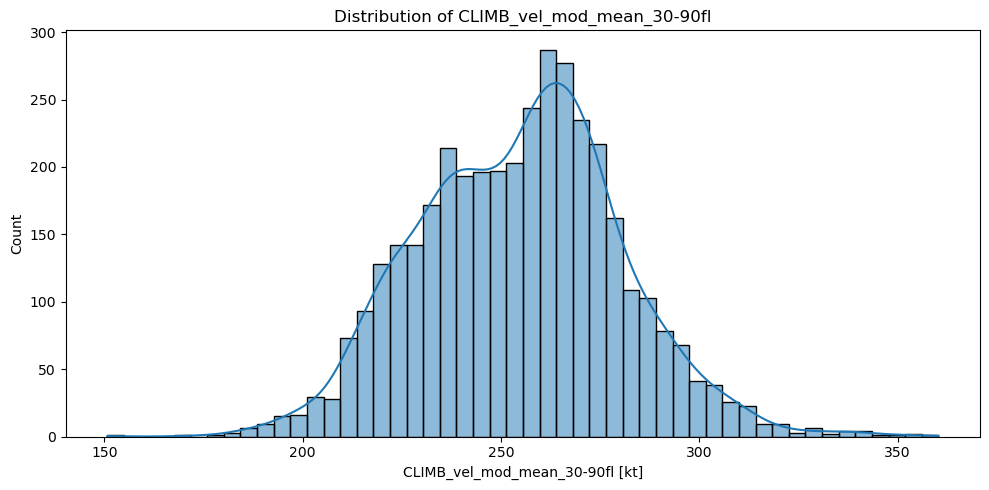

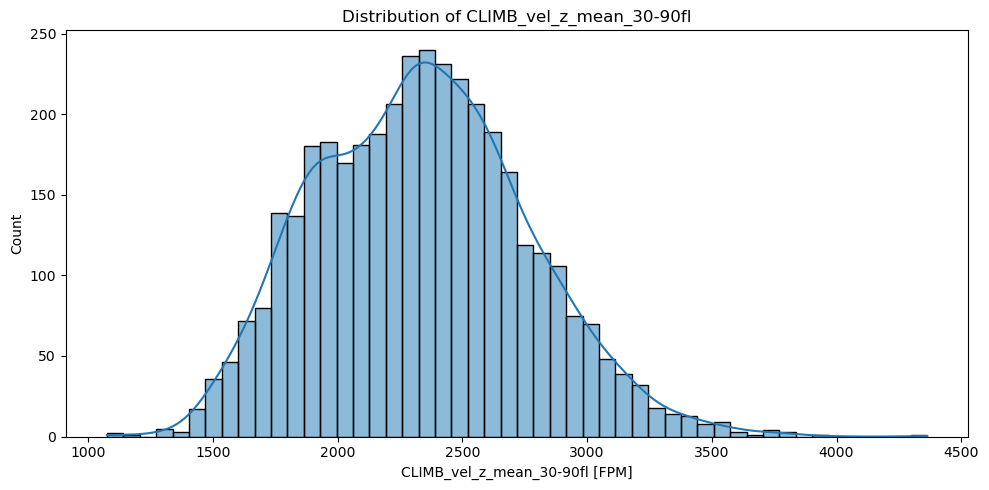

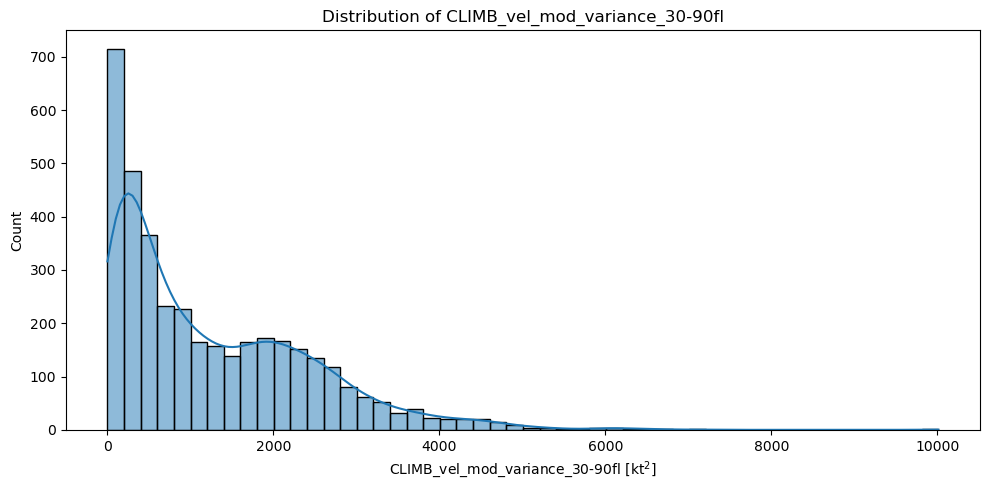

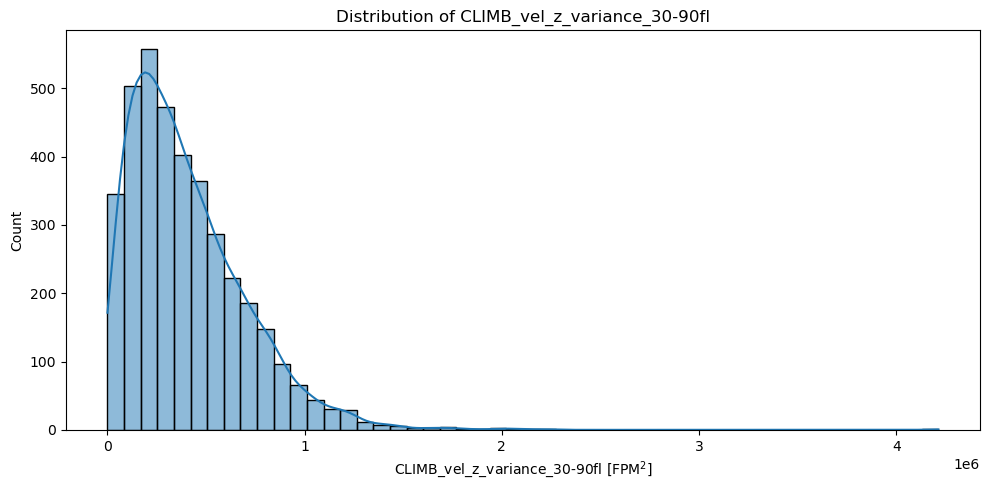

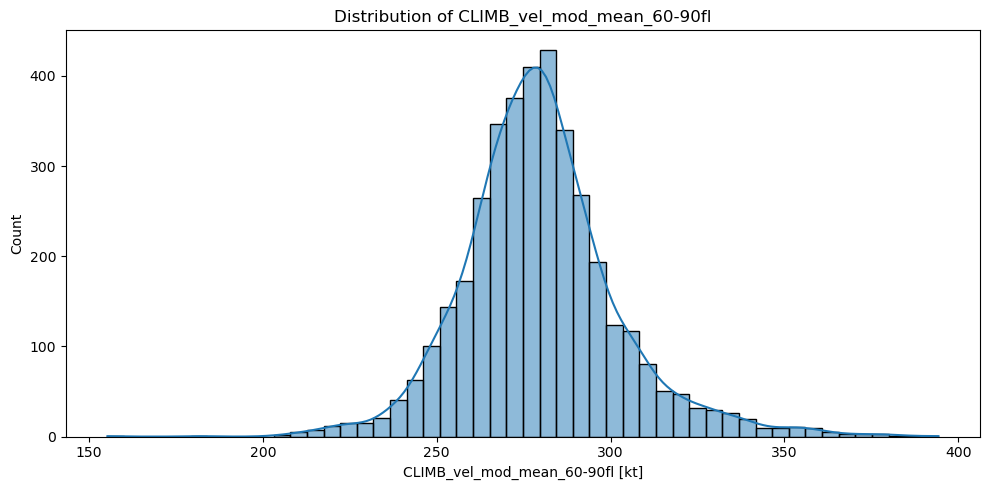

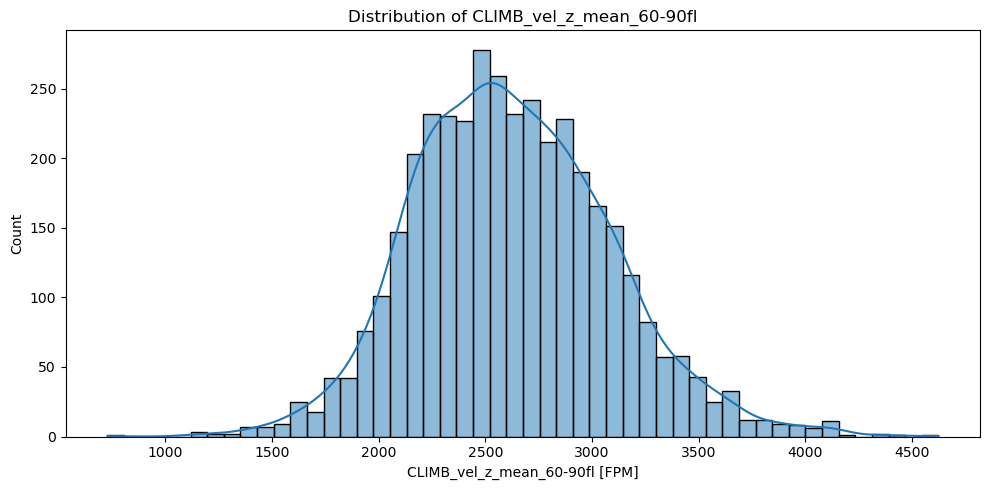

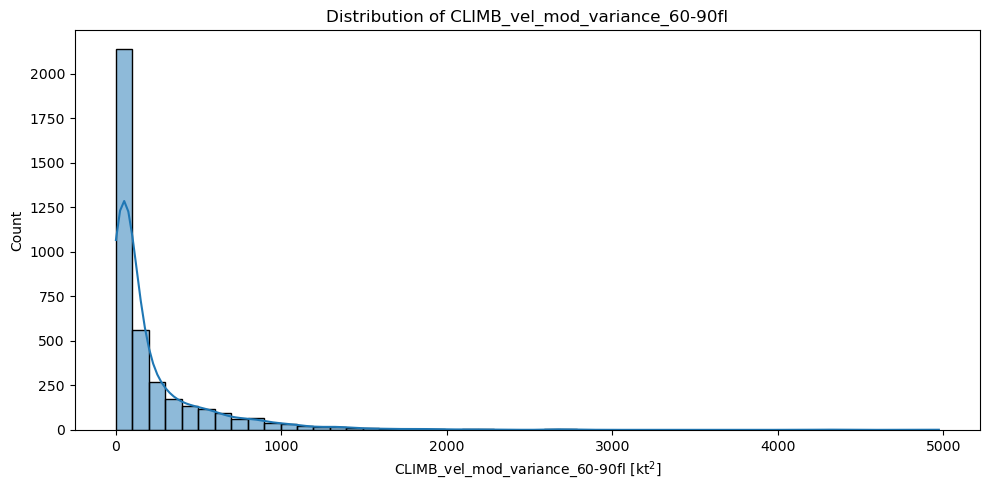

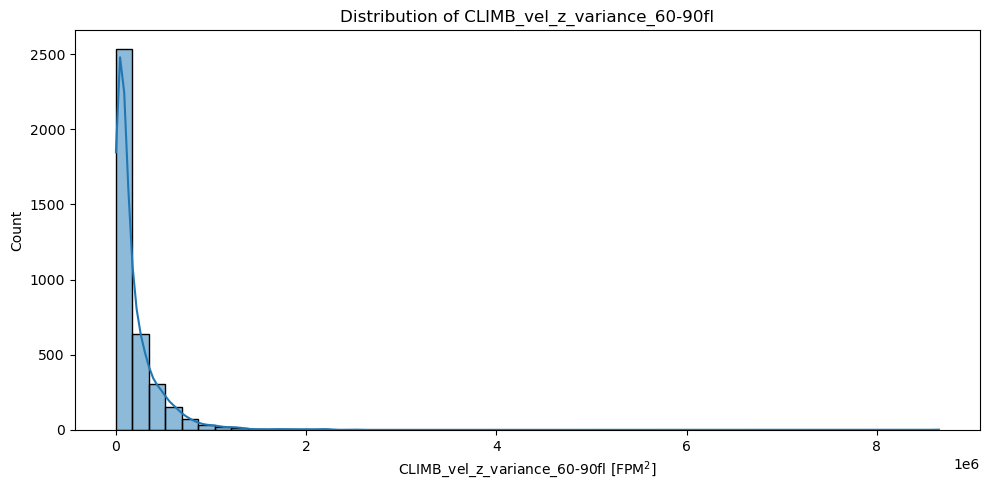

In [16]:
columns = ['CLIMB_vel_mod_mean_0-30fl', 'CLIMB_vel_mod_variance_0-30fl', 'CLIMB_vel_z_mean_0-30fl', 'CLIMB_vel_z_variance_0-30fl', 'CLIMB_vel_mod_mean_0-60fl', 'CLIMB_vel_mod_variance_0-60fl', 'CLIMB_vel_z_mean_0-60fl', 'CLIMB_vel_z_variance_0-60fl', 'CLIMB_vel_mod_mean_0-90fl', 'CLIMB_vel_mod_variance_0-90fl', 'CLIMB_vel_z_mean_0-90fl', 'CLIMB_vel_z_variance_0-90fl', 'CLIMB_vel_mod_mean_30-60fl', 'CLIMB_vel_mod_variance_30-60fl', 'CLIMB_vel_z_mean_30-60fl', 'CLIMB_vel_z_variance_30-60fl', 'CLIMB_vel_mod_mean_30-90fl', 'CLIMB_vel_mod_variance_30-90fl', 'CLIMB_vel_z_mean_30-90fl', 'CLIMB_vel_z_variance_30-90fl', 'CLIMB_vel_mod_mean_60-90fl', 'CLIMB_vel_mod_variance_60-90fl', 'CLIMB_vel_z_mean_60-90fl', 'CLIMB_vel_z_variance_60-90fl']  
# fig, axes = plt.subplots(6, 4, figsize=(50, 25))  
# axes = axes.flatten()  
# for i, col in enumerate(columns):
#     sns.histplot(data[col], bins=50, edgecolor='black', stat='count', kde=True, ax=axes[i])
#     axes[i].set_xlabel(f'{col}')
#     axes[i].set_ylabel('Number of flights')
#     axes[i].set_title(f'Distribution of {col}')

# plt.tight_layout()  # Adjust layout to prevent overlap
# plt.show()


for col in vel_intervals:
    plt.figure(figsize=(10, 5))
    sns.histplot(data[col], bins=50, edgecolor='black', stat='count', kde=True)
    if 'vel_mod_mean' in col:
        plt.xlabel(f'{col} [kt]')
    if 'vel_mod_variance' in col:
        plt.xlabel(f'{col} [kt$^2$]')
    if 'vel_z_mean' in col:
        plt.xlabel(f'{col} [FPM]')
    if 'vel_z_variance' in col:
        plt.xlabel(f'{col} [FPM$^2$]')                        
    plt.ylabel('Count')
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.savefig(f'{col}.png')  # Save the figure as PNG using the column name
    plt.show()

In [16]:
# from tqdm import tqdm
# data[vel_intervals] = np.nan

# for flight_id in tqdm(data['flightKey'], desc="Processing flights"):
#     query_df = execute_query(cnn, flight_id)
#     initial_vel = get_initial_vel(data, flight_id, query_df)
#     data.loc[data['flightKey'] == flight_id, ['total_pts_trace'] + vel_intervals] = ( 
#         len(query_df),                                                                                                                                                                                                    
#         initial_vel.get('CLIMB_vel_mod_mean_0-30fl', np.nan),
#         initial_vel.get('CLIMB_vel_z_mean_0-30fl', np.nan),
#         initial_vel.get('CLIMB_vel_mod_variance_0-30fl', np.nan),
#         initial_vel.get('CLIMB_vel_z_variance_0-30fl', np.nan),
#         initial_vel.get('CLIMB_vel_mod_mean_0-60fl', np.nan),
#         initial_vel.get('CLIMB_vel_z_mean_0-60fl', np.nan),
#         initial_vel.get('CLIMB_vel_mod_variance_0-60fl', np.nan),
#         initial_vel.get('CLIMB_vel_z_variance_0-60fl', np.nan),
#         initial_vel.get('CLIMB_vel_mod_mean_0-90fl', np.nan),
#         initial_vel.get('CLIMB_vel_z_mean_0-90fl', np.nan),
#         initial_vel.get('CLIMB_vel_mod_variance_0-90fl', np.nan),
#         initial_vel.get('CLIMB_vel_z_variance_0-90fl', np.nan),
#         initial_vel.get('CLIMB_vel_mod_mean_30-60fl', np.nan),
#         initial_vel.get('CLIMB_vel_z_mean_30-60fl', np.nan),
#         initial_vel.get('CLIMB_vel_mod_variance_30-60fl', np.nan),
#         initial_vel.get('CLIMB_vel_z_variance_30-60fl', np.nan),
#         initial_vel.get('CLIMB_vel_mod_mean_30-90fl', np.nan),
#         initial_vel.get('CLIMB_vel_z_mean_30-90fl', np.nan),
#         initial_vel.get('CLIMB_vel_mod_variance_30-90fl', np.nan),
#         initial_vel.get('CLIMB_vel_z_variance_30-90fl', np.nan),
#         initial_vel.get('CLIMB_vel_mod_mean_60-90fl', np.nan),
#         initial_vel.get('CLIMB_vel_z_mean_60-90fl', np.nan),
#         initial_vel.get('CLIMB_vel_mod_variance_60-90fl', np.nan),
#         initial_vel.get('CLIMB_vel_z_variance_60-90fl', np.nan)
#     )

# data.to_csv('data_with_full_climbing_vel.csv', index=False)

Processing flights:   0%|          | 0/44895 [00:00<?, ?it/s]

Processing flights: 100%|██████████| 44895/44895 [2:24:45<00:00,  5.17it/s]  


In [20]:
data = data.drop(columns=['CLIMB_vel_mod_mean_30fl', 'CLIMB_vel_mod_mean_60fl', 'CLIMB_vel_mod_mean_90fl', 'CLIMB_vel_z_mean_30fl', 'CLIMB_vel_z_mean_60fl', 'CLIMB_vel_z_mean_90fl'])

In [21]:
list(data.columns)

['flightKey',
 'CFMUflightKey',
 'callsign',
 'adep',
 'ades',
 'ADEPLat',
 'ADEPLong',
 'ADESLat',
 'ADESLong',
 'routeType',
 'aircraftType',
 'aircraftOperator',
 'operatingAircraftOperator',
 'ATOT_track',
 'ALDT_track',
 'airlineCode',
 'tow',
 'flightType',
 'wake',
 'RECATwake',
 'EngineType',
 'Description',
 'numberOfEngines',
 'aircraftNumber',
 'aircraftRegistration',
 'previousAdes',
 'altAdes',
 'cruiseSpeed',
 'cruiseLevel',
 'arrivalRunway',
 'departureRunway',
 'mtow',
 'mlw',
 'oew',
 'mfc',
 'vmo',
 'mmo',
 'ceiling',
 'range',
 'dtPhaseStart_CLIMB',
 'dtPhaseEnd_CLIMB',
 'dtPhaseStart_CRUISE',
 'dtPhaseEnd_CRUISE',
 'dtPhaseStart_DESCENT',
 'dtPhaseEnd_DESCENT',
 'ATOT_track_hour',
 'ATOT_track_day',
 'ALDT_track_hour',
 'ALDT_track_day',
 'flight_duration',
 'CLIMB_duration',
 'CRUISE_duration',
 'DESCENT_duration',
 'total_distance',
 'CLIMB_distance',
 'CRUISE_distance',
 'DESCENT_distance',
 'CLIMB_modo_c_median',
 'CLIMB_modo_c_variance',
 'CLIMB_vel_mod_median'

In [22]:
data.to_csv('data_with_full_climbing_vel.csv', index=False)

In [17]:
data[vel_intervals].isnull().sum()

CLIMB_vel_mod_mean_0-30fl         25673
CLIMB_vel_z_mean_0-30fl           25673
CLIMB_vel_mod_variance_0-30fl     25877
CLIMB_vel_z_variance_0-30fl       25877
CLIMB_vel_mod_mean_0-60fl         24659
CLIMB_vel_z_mean_0-60fl           24659
CLIMB_vel_mod_variance_0-60fl     24707
CLIMB_vel_z_variance_0-60fl       24707
CLIMB_vel_mod_mean_0-90fl         24558
CLIMB_vel_z_mean_0-90fl           24558
CLIMB_vel_mod_variance_0-90fl     24578
CLIMB_vel_z_variance_0-90fl       24578
CLIMB_vel_mod_mean_30-60fl        24660
CLIMB_vel_z_mean_30-60fl          24660
CLIMB_vel_mod_variance_30-60fl    24709
CLIMB_vel_z_variance_30-60fl      24709
CLIMB_vel_mod_mean_30-90fl        24559
CLIMB_vel_z_mean_30-90fl          24559
CLIMB_vel_mod_variance_30-90fl    24579
CLIMB_vel_z_variance_30-90fl      24579
CLIMB_vel_mod_mean_60-90fl        24562
CLIMB_vel_z_mean_60-90fl          24562
CLIMB_vel_mod_variance_60-90fl    24581
CLIMB_vel_z_variance_60-90fl      24581
dtype: int64

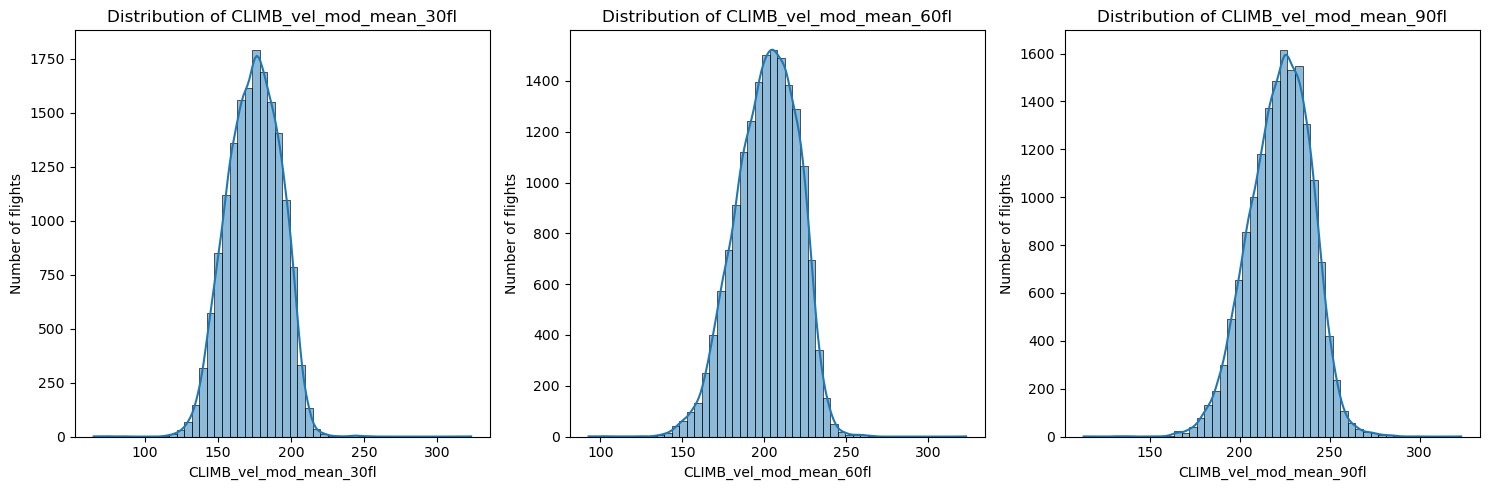

In [15]:
columns = ['CLIMB_vel_mod_mean_30fl', 'CLIMB_vel_mod_mean_60fl', 'CLIMB_vel_mod_mean_90fl']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))  
axes = axes.flatten()  
for i, col in enumerate(columns):
    sns.histplot(data[col], bins=50, edgecolor='black', stat='count', kde=True, ax=axes[i])
    axes[i].set_xlabel(f'{col}')
    axes[i].set_ylabel('Number of flights')
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

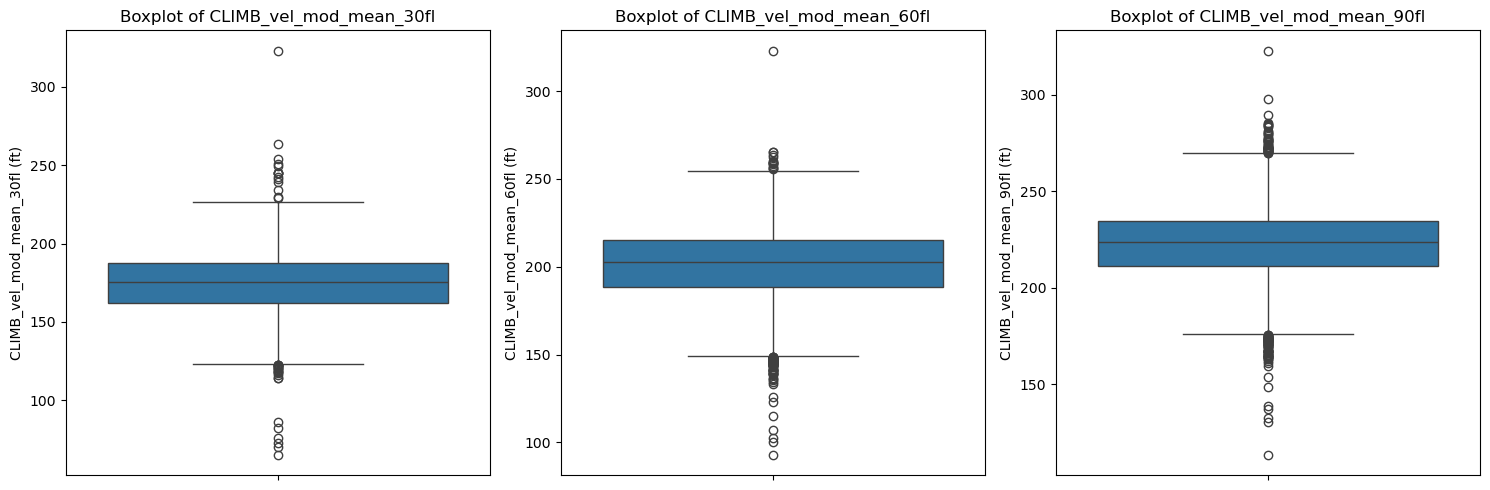

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))  
axes = axes.flatten()  

columns = ['CLIMB_vel_mod_mean_30fl', 'CLIMB_vel_mod_mean_60fl', 'CLIMB_vel_mod_mean_90fl']

for c in columns:
    quartiles = data[c].describe()
    iqr = (quartiles['75%'] - quartiles['25%'])
    upper = quartiles['75%'] + (iqr*1.5)
    lower = quartiles['25%'] - (iqr*1.5)
    
for i, col in enumerate(columns):
    sns.boxplot(y=data[col], ax=axes[i])
    axes[i].set_ylabel(f'{col} (ft)')
    axes[i].set_title(f'Boxplot of {col}')

# Hide the empty subplot (if any)
if len(columns) < len(axes):
    axes[len(columns)].axis('off')

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

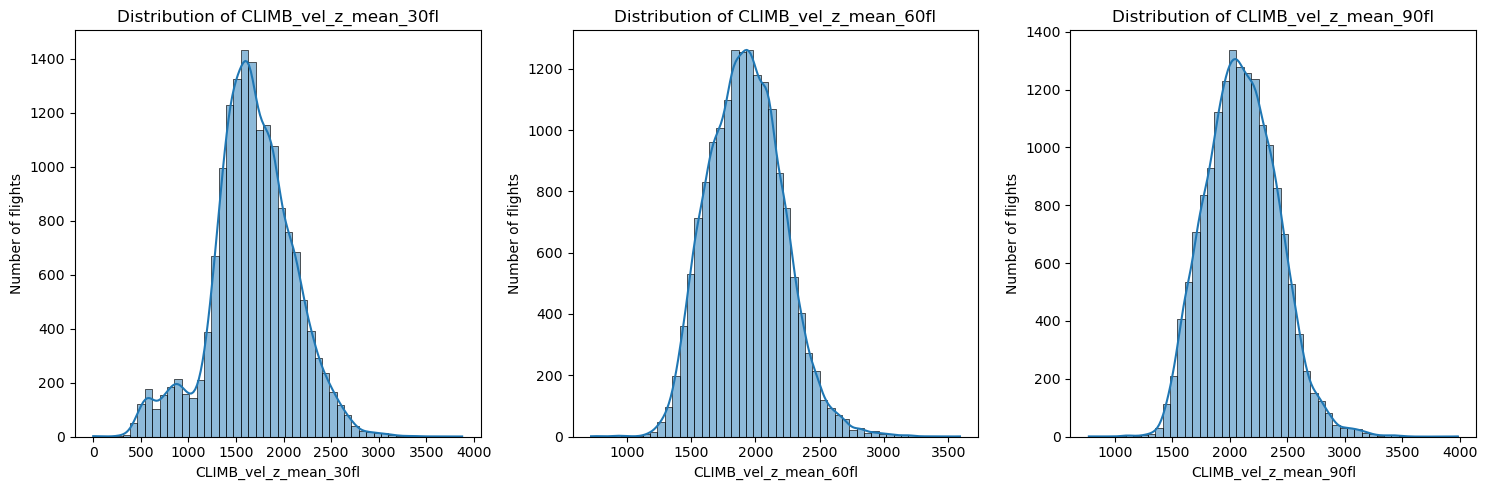

In [31]:
columns = ['CLIMB_vel_z_mean_30fl', 'CLIMB_vel_z_mean_60fl', 'CLIMB_vel_z_mean_90fl']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))  
axes = axes.flatten()  
for i, col in enumerate(columns):
    sns.histplot(data[col], bins=50, edgecolor='black', stat='count', kde=True, ax=axes[i])
    axes[i].set_xlabel(f'{col}')
    axes[i].set_ylabel('Number of flights')
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()  
plt.show()

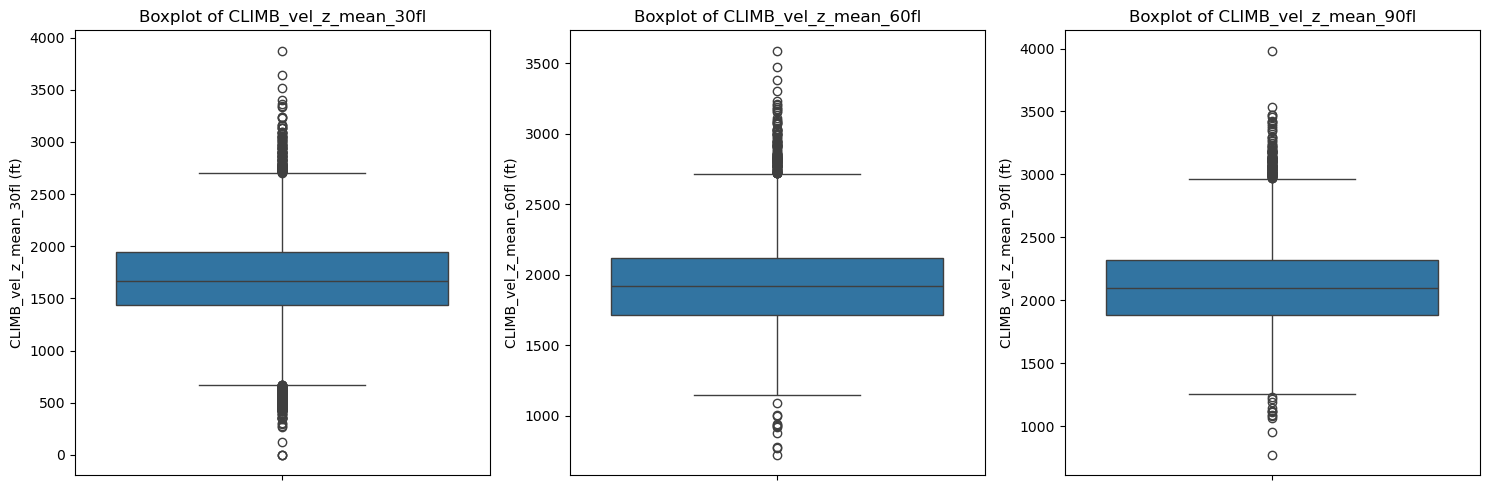

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))  
axes = axes.flatten()  

columns = ['CLIMB_vel_z_mean_30fl', 'CLIMB_vel_z_mean_60fl', 'CLIMB_vel_z_mean_90fl']

for c in columns:
    quartiles = data[c].describe()
    iqr = (quartiles['75%'] - quartiles['25%'])
    upper = quartiles['75%'] + (iqr*1.5)
    lower = quartiles['25%'] - (iqr*1.5)
    
for i, col in enumerate(columns):
    sns.boxplot(y=data[col], ax=axes[i])
    axes[i].set_ylabel(f'{col} (ft)')
    axes[i].set_title(f'Boxplot of {col}')

# Hide the empty subplot (if any)
if len(columns) < len(axes):
    axes[len(columns)].axis('off')

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

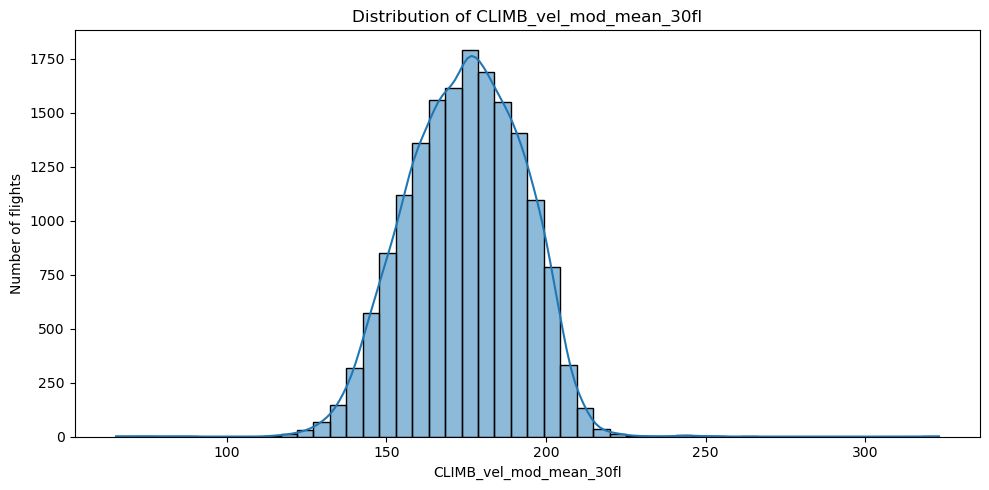

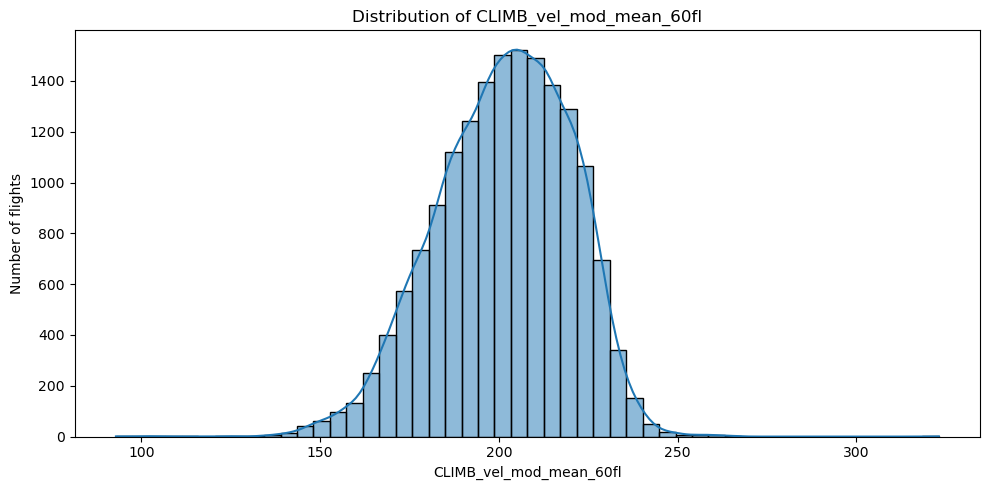

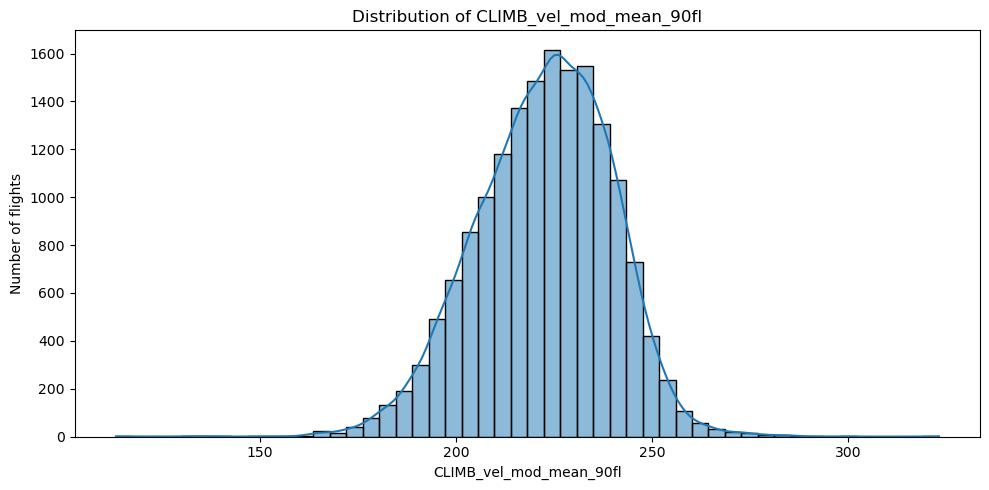

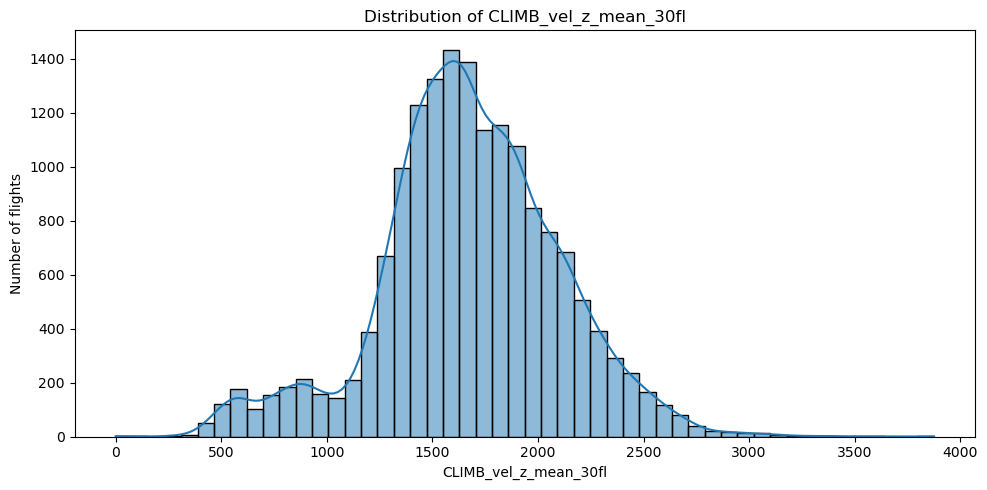

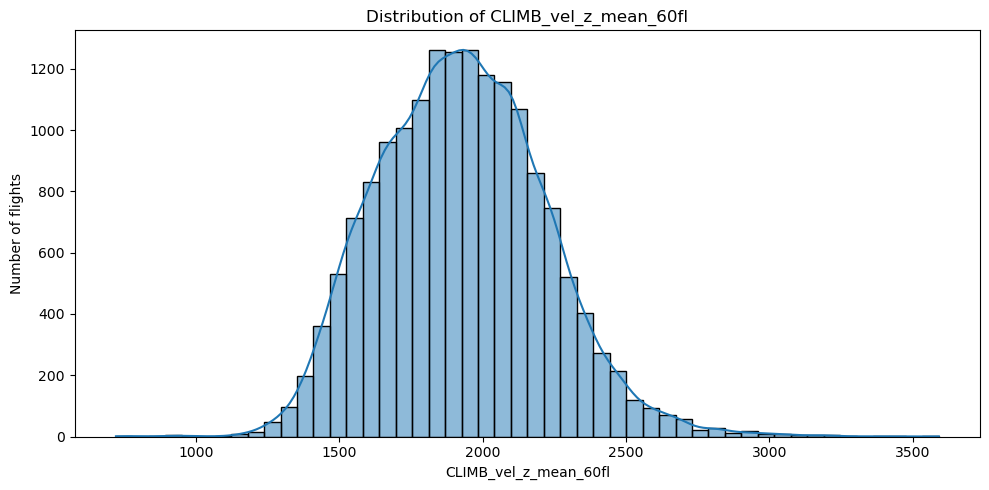

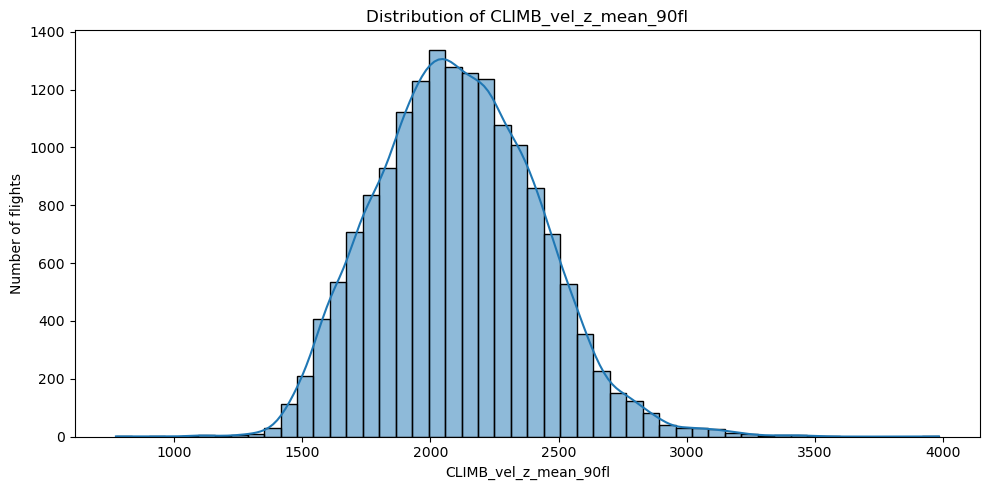

In [16]:
initial_vel_cols = ['CLIMB_vel_mod_mean_30fl', 'CLIMB_vel_mod_mean_60fl', 'CLIMB_vel_mod_mean_90fl', 'CLIMB_vel_z_mean_30fl', 'CLIMB_vel_z_mean_60fl', 'CLIMB_vel_z_mean_90fl'] 

for col in initial_vel_cols:
    plt.figure(figsize=(10, 5))
    sns.histplot(data[col], bins=50, edgecolor='black', stat='count', kde=True)
    plt.xlabel(f'{col}')
    plt.ylabel('Number of flights')
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

# climbing features: drag, thrust

SI UNITS

In [16]:
# FEET2METER = 0.3048
# NM2METER = 1852.
# KTS2MS = NM2METER/3600.

In [17]:
# class WrapperOpenAP:
#     """
#     A wrapper to OpenAP that takes a dataframe as input, this allows to deal with SI/aeronautical units stuff
#     We also added a method to extract the drag as a second degree polynomial of the mass.
#     """
#     _dragsynonym = {
#         "a21n":"a321",
#         "crj9":"e75l",
#         "bcs3":"a319",
#         "at76":"e75l",
#         "b763":"b752",
#         "bcs1":"a319",
#         "b39m":"b739",
#         "a310":"a319",
#         "a318":"a319",
#         "b773":"b772",
#         "c56x":"c550",
#         "e290":"e190"
#     }
#     _thrustsynonym = _dragsynonym
#     def __init__(self,ac):
#         ac = ac.lower()
#         self.thrust_model = openap.Thrust(self._thrustsynonym.get(ac,ac))
#         self.drag_model = openap.Drag(self._dragsynonym.get(ac,ac))
#         self.aircraft = openap.prop.aircraft(self._thrustsynonym.get(ac,ac))
#     def convert(self,df):
#         tas_kt = df.tas / KTS2MS
#         alt_ft = df.altitude / FEET2METER
#         rocd = df.vertical_rate / FEET2METER * 60
#         return tas_kt, alt_ft,rocd
#     def drag_polynomial(self,df):
#         tas,alt,_ = self.convert(df);del df
#         # drag = c_0 + c_2 * m ** 2
#         masses = np.array([0,10000])
#         assert masses[0] == 0
#         # drags: masses x points
#         drags = self.drag_model.clean(masses[:,np.newaxis],tas,alt)
#         # c_2 = (drag - c_0) / m**2
#         drags[1,:] = (drags[1,:]-drags[0,:]) / masses[1] ** 2
#         return drags.T # points x coeffs
#     def thrust_climb(self, df, use_rocd=False):
#         tas,alt,rocd = self.convert(df);del df
#         if not use_rocd:
#             rocd = 0
#         return self.thrust_model.climb(tas=tas, alt=alt, roc=rocd)
#     def thrust_descent(self, df):
#         tas,alt,_ = self.convert(df);del df
#         return self.thrust_model.descent_idle(tas=tas, alt=alt)

In [18]:
# def energy_rate(df, periods=5):
#     tempISA = isa.temperature(df.modo_c)
#     # tau = df.temperature / tempISA
#     g_0 = 9.80665
#     dalt = df.modo_c - df.modo_c.shift(periods=periods)
#     tas2 = df.modo_c ** 2
#     dtas2 = tas2 - tas2.shift(periods=periods)
#     dt = (df.timestamp - df.timestamp.shift(periods=periods)).dt.total_seconds()
#     dwx = df.u_component_of_wind - df.u_component_of_wind.shift(periods=periods)
#     dwy = df.v_component_of_wind - df.v_component_of_wind.shift(periods=periods)
#     dewind = dwx * df.tasx + dwy * df.tasy
#     e = (g_0 * dalt * tau + 0.5 * dtas2 + dewind) / dt
#     return np.clip(e.values,-400,300)

In [19]:
# def compute_mass(base_df, flight_key, df, is_climb, periods, thresh_dt, cthrust):
#     lac = base_df[base_df['flightKey'] == flight_key]['aircraft_tyop']
#     n = df.shape[0]
#     thrust = np.empty(n)
#     thrust[:]=np.nan
#     drag_poly = np.empty((n,2))
#     drag_poly[:]=np.nan
#     for ac in lac:
#         if pd.isna(ac):
#             print("nan detected")
#             raise Exception
#         mask = (df.aircraft_type == ac).to_numpy(dtype=bool,na_value=False)
#         dfac = df.query("aircraft_type == @ac")
#         apmodel = WrapperOpenAP(ac)
#         thrust_ac =  cthrust * apmodel.thrust_climb(dfac)
#         drag_poly_ac = apmodel.drag_polynomial(dfac)
#         thrust[mask] = thrust_ac
#         drag_poly[mask] = drag_poly_ac
#     e_rate = energy_rate(df,periods,thresh_dt)
#     total_energy_poly = total_energy_polynomial_equation(thrust,drag_poly,e_rate,df.tas.values)
#     sols =total_energy_poly.roots2()
#     which = 0 # if is_climb else 1
#     return pd.DataFrame({"masses":sols[:,which],"e_rate":e_rate},index=df.index)

In [16]:
# from tqdm import tqdm

# initial_modo_c_values = []
# for flight_id in tqdm(data['flightKey'], desc="Processing flights"):
#     query_df = execute_query(cnn, flight_id)
#     initial_modo_c_values.append([flight_id] + list(query_df['modo_c'][:20]))

# stacked_modo_c = pd.DataFrame(initial_modo_c_values)
# column_names = ['flight_id'] + [f'modo_c_{i+1}' for i in range(stacked_modo_c.shape[1] - 1)]

# # Save to CSV
# stacked_modo_c.to_csv('initial_modo_c_values.csv', header=False, index=False)

Processing flights:   0%|          | 0/44895 [00:00<?, ?it/s]

Processing flights: 100%|██████████| 44895/44895 [1:47:03<00:00,  6.99it/s]  


In [6]:
# from tqdm import tqdm
# data[flight_profile_cols] = np.nan

# for flight_id in tqdm(data['flightKey'], desc="Processing flights"):
#     query_df = execute_query(cnn, flight_id)
#     flight_profile = get_flight_profile(data, flight_id, query_df)
    
#     data.loc[data['flightKey'] == flight_id, ['CLIMB_modo_c_median', 'CLIMB_modo_c_variance', 'CLIMB_vel_mod_median', 'CLIMB_vel_mod_variance', 'CLIMB_vel_z_median', 'CLIMB_vel_z_variance', 'CLIMB_delta_modo_c', 
#     'CRUISE_modo_c_median', 'CRUISE_modo_c_variance', 'CRUISE_vel_mod_median', 'CRUISE_vel_mod_variance', 'CRUISE_vel_z_median', 'CRUISE_vel_z_variance', 'CRUISE_delta_modo_c',
#     'DESCENT_modo_c_median', 'DESCENT_modo_c_variance', 'DESCENT_vel_mod_median', 'DESCENT_vel_mod_variance', 'DESCENT_vel_z_median', 'DESCENT_vel_z_variance', 'DESCENT_delta_modo_c']] = ( 
                                                                                                                                                                                            
#         flight_profile.get('CLIMB_modo_c_median', np.nan),
#         flight_profile.get('CLIMB_modo_c_variance', np.nan),
#         flight_profile.get('CLIMB_vel_mod_median', np.nan),
#         flight_profile.get('CLIMB_vel_mod_variance', np.nan),
#         flight_profile.get('CLIMB_vel_z_median', np.nan),
#         flight_profile.get('CLIMB_vel_z_variance', np.nan),
#         flight_profile.get('CLIMB_delta_modo_c', np.nan),
        
#         flight_profile.get('CRUISE_modo_c_median', np.nan),
#         flight_profile.get('CRUISE_modo_c_variance', np.nan),
#         flight_profile.get('CRUISE_vel_mod_median', np.nan),
#         flight_profile.get('CRUISE_vel_mod_variance', np.nan),
#         flight_profile.get('CRUISE_vel_z_median', np.nan),
#         flight_profile.get('CRUISE_vel_z_variance', np.nan),
#         flight_profile.get('CRUISE_delta_modo_c', np.nan),
        
#         flight_profile.get('DESCENT_modo_c_median', np.nan),
#         flight_profile.get('DESCENT_modo_c_variance', np.nan),
#         flight_profile.get('DESCENT_vel_mod_median', np.nan),
#         flight_profile.get('DESCENT_vel_mod_variance', np.nan),
#         flight_profile.get('DESCENT_vel_z_median', np.nan),
#         flight_profile.get('DESCENT_vel_z_variance', np.nan),
#         flight_profile.get('DESCENT_delta_modo_c', np.nan)                                                
#     )

# for col in flight_profile_cols:
#     median_distance = data.groupby('wake')[col].transform('median')
#     data[col] = data[col].fillna(median_distance)

# data.to_csv('data_with_flight_profile.csv', index=False)

In [20]:
# columns = ['DESCENT_modo_c_median', 'DESCENT_modo_c_variance', 'DESCENT_vel_mod_median', 'DESCENT_vel_mod_variance', 'DESCENT_vel_z_median', 'DESCENT_vel_z_variance', 'DESCENT_delta_modo_c']
# col = 'DESCENT_delta_modo_c'
# plt.figure(figsize=(10, 5))
# sns.histplot(data[col], bins=50, edgecolor='black', stat='count', kde=True)
# plt.xlabel(f'{col}')
# plt.ylabel('Number of flights')
# plt.title(f'Distribution of {col}')

In [14]:
# from tqdm import tqdm
# data[initial_vel_cols] = np.nan

# for flight_id in tqdm(data['flightKey'], desc="Processing flights"):
#     query_df = execute_query(cnn, flight_id)
#     initial_vel = get_initial_vel(data, flight_id, query_df)
#     data.loc[data['flightKey'] == flight_id, ['total_pts_trace', 'CLIMB_vel_mod_mean_30fl', 'CLIMB_vel_mod_mean_60fl', 'CLIMB_vel_mod_mean_90fl', 'CLIMB_vel_z_mean_30fl', 'CLIMB_vel_z_mean_60fl', 'CLIMB_vel_z_mean_90fl']] = ( 
#         len(query_df),                                                                                                                                                                                                    
#         initial_vel.get('CLIMB_vel_mod_mean_30fl', np.nan),
#         initial_vel.get('CLIMB_vel_mod_mean_60fl', np.nan),
#         initial_vel.get('CLIMB_vel_mod_mean_90fl', np.nan),
#         initial_vel.get('CLIMB_vel_z_mean_30fl', np.nan),
#         initial_vel.get('CLIMB_vel_z_mean_60fl', np.nan),
#         initial_vel.get('CLIMB_vel_z_mean_90fl', np.nan), 
#     )

# data.to_csv('data_with_climbing_vel.csv', index=False)

Processing flight distances:   0%|          | 7/44895 [00:00<1:12:46, 10.28it/s]

Processing flight distances: 100%|██████████| 44895/44895 [2:15:58<00:00,  5.50it/s]  


In [30]:
# columns = ['CRUISE_modo_c_median', 'CRUISE_modo_c_variance', 'CRUISE_vel_mod_median', 'CRUISE_vel_mod_variance', 'CRUISE_vel_z_median', 'CRUISE_vel_z_variance', 'CRUISE_delta_modo_c']

# col = 'CLIMB_vel_z_mean_90fl'
# plt.figure(figsize=(10, 5))
# sns.histplot(data[col], bins=50, edgecolor='black', stat='count', kde=True)
# plt.xlabel(f'{col}')
# plt.ylabel('Number of flights')
# plt.title(f'Distribution of {col}')

In [36]:
# import requests
# from typing import List, Dict

# # Fetch elevations for given ICAO codes
# def fetch_elevations(icao_codes: List[str], api_token: str) -> List[Dict[str, any]]:
#     base_url = 'https://airportdb.io/api/v1/airport/'
#     headers = {'Accept': 'application/json'}

#     airport_data = []

#     for icao in icao_codes:
#         url = f'{base_url}{icao}?apiToken={api_token}'
#         try:
#             response = requests.get(url, headers=headers)
#             response.raise_for_status()
#             airport_json = response.json()

#             elevation = airport_json.get('elevation_ft')

#             airport_data.append({
#                 'icao': icao,
#                 'elevation_ft': elevation
#             })
#         except requests.HTTPError as http_err:
#             print(f'HTTP error occurred for {icao}: {http_err}')
#             airport_data.append({
#                 'icao': icao,
#                 'elevation_ft': None
#             })
#         except Exception as err:
#             print(f'Other error occurred for {icao}: {err}')
#             airport_data.append({
#                 'icao': icao,
#                 'elevation_ft': None
#             })

#     return airport_data


# # Usage example
# set1 = set(data['adep'].unique())
# set2 = set(data['ades'].unique())
# icao_list = list(set1.union(set2))

# # API token
# api_token = 'f059c63acd26efd43d97e085902bcdb35b786f8edc4553e8b5e5b954fe3bae453abe54e5870777bc92af154237170d31'

# # Get airport elevation data
# icao_elevations = fetch_elevations(icao_list, api_token)

HTTP error occurred for LEMI: 404 Client Error: Not Found for url: https://airportdb.io/api/v1/airport/LEMI?apiToken=f059c63acd26efd43d97e085902bcdb35b786f8edc4553e8b5e5b954fe3bae453abe54e5870777bc92af154237170d31
HTTP error occurred for DTNH: 404 Client Error: Not Found for url: https://airportdb.io/api/v1/airport/DTNH?apiToken=f059c63acd26efd43d97e085902bcdb35b786f8edc4553e8b5e5b954fe3bae453abe54e5870777bc92af154237170d31


In [47]:
# icao_elevations_df = pd.DataFrame(icao_elevations)
# icao_elevations_df.loc[icao_elevations_df['icao'] == 'LEMI', 'elevation_ft'] = 644.0
# icao_elevations_df.loc[icao_elevations_df['icao'] == 'DTNH', 'elevation_ft'] = 21.0

# icao_elevations_df.to_csv("icao_elevations.csv", index=False)